In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.append('../')  # Add parent directory to path for imports
from trmoke_analysis.datareduction import DataProposal

## Initializing the Data Proposal

We start by initializing the proposal using the `DataProposal` class. The proposal configuration includes:

Typing the proposal object's name in a cell displays a summary table of all scans in the proposal.

- **Proposal name**: Typically formatted as `YYYY_MM_<short_title>` (e.g., `2026_04_PtCo_SL`)

- **Data directory**: Path to the raw data (can be local or remote)-

- **Spice path**: Separate directory for spice metadata (needed when write permissions are restricted, as with UDKM measurement servers)

In [2]:
#prop = DataProposal("2026_04_PtCo_SL", "Remote", overwrite=True)


prop = DataProposal(
    "2026_04_PtCo_SL", # Proposal ID
    "Remote/Data", # Path to raw data directory
    spice_path="Remote/Spice", # Path to remote spice directory (if differeqnt from data directory)
    overwrite=True) # Always copy all the data from the remote to the local data directory
prop # Display an overview table of the scans in the proposal

Syncing 19/19 files from server...


100%|██████████| 19/19 [00:00<00:00, 3845.20it/s]

Sync complete.


Starting with a new spice configuration.


,scan_id,sample_name,scan_parameter,frames,delay_values,fluence_values,field_values
0,0000,SL3,Unknown,444,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
1,0001,SL3,Unknown,224,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
2,0002,SL3,Unknown,444,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
3,0003,SL3,Unknown,444,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
4,0004,SL3,Unknown,444,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
5,0005,SL3,Unknown,444,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
6,0006,SL3,Unknown,6660,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
7,0006_processed,SL3,Unknown,3330,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
8,0007,SL3,Unknown,36,-1.00 ... 10.00 ps (111),11.50 °,0.50 V
9,0008,SL3,Unknown,32,-1.00 ... 10.00 ps (111),11.50 °,0.50 V


## Accessing Individual Scans

Individual scans within the proposal are accessible through the `data` attribute of the proposal object.

In [3]:
prop.data

ScanAccessor: 22 scans found. Use r/p/f/b prefix + scan number (e.g. r0001).

## Loading Scan Data

Individual scans are accessed using a unique scan ID with a prefix indicating the data type:

- `r` – Raw data
- `p` – Processed data  
- `f` – Fluence calibrations
- `b` – Field calibrations


Scans are stored as NetCDF files containing raw data and metadata. The raw data is organized as a 2D table with all datapoints and parameters for each frame, sorted by an increasing frame index.After processing, the data structure is transformed into a more intuitive multi-dimensional format where each parameter becomes its own dimension, enabling easy slicing and indexing.


In [6]:
prop.data.r0017

<xarray.Dataset> Size: 3MB
Dimensions:         (detector: 3, frames: 38400)
Coordinates:
  * detector        (detector) int64 24B 0 1 2
  * frames          (frames) int64 307kB 0 1 2 3 4 ... 38396 38397 38398 38399
Data variables:
    detector_data   (detector, frames) float64 922kB 0.1921 0.193 ... 1.079
    chopper_signal  (frames) float64 307kB 0.002095 5.0 ... 0.002919 5.0
    diode_signal    (frames) float64 307kB -0.1854 -1.471 ... -0.1865 -1.505
    delay           (frames) float64 307kB -10.0 -10.0 -9.0 ... 800.0 800.0
    fluence         (frames) float64 307kB 40.0 40.0 40.0 ... 40.1 40.1 40.1
    field           (frames) float64 307kB 900.0 900.0 900.0 ... -300.0 -300.0
    loop            (frames) float64 307kB 0.0 0.0 0.0 0.0 ... 2.0 2.0 2.0 2.0
Attributes: (12/21)
    sample_name:         Ni20
    proposal_name:       Ticia_BA
    fluence_values:      [40.  20.  10.  30.  40.1]
    field_values:        [900. 300.]
    delay_values:        [-1.00000000e+01 -9.00000000e+00 -8.00000000e+00 -7....
    fluence_unit:        mJ/cm²
    ...                  ...
    diode_channel:       3
    TRMOKE_version:      2.2.1
    setup:               FemtoMag PMOKE
    timestamp:           20260519_161641
    scan_id:             0021
    secondary_position:  -1

## Spice Configuration

Spices are essential metadata parameters in the data reduction pipeline. Following the nx5d package principles, spices undergo iterative refinement throughout processing, allowing you to refine parameters and reprocess data as needed.

Spices are provided as a dictionary to the proposal. The processing recipe determines which spices are actually used. Default values are available if not specified.

### Common Spice Parameters for trMOKE Analysis

- **`t0`**: Position of true time-zero in the experiment (in picoseconds)
- **`sigma`**: Sigma-clipping parameter for outlier removal (typically unnecessary for clean data)
- **`sign_i`**: Sign reversal for detector `i` (accommodates arbitrary signal polarity)


### Spice Initialization (Seeding)
Initializing spices is called "seeding." After seeding, the spice object displays a changelog showing which spice values have changed across scan indices. Initially, this table contains one row (scan 0) with the initial seed values.


In [7]:
init_spice = {'t0': 0}
prop.spice.seed(init_spice)
prop.spice

,t0
scan_id,
0,0.0


## Processing Scans

One or more scans are processed using the `process()` method. The program automatically:

1. Determines the scan type (from explicit `scan_parameter` attribute or by inferring from unique parameter values)
2. Selects and applies the appropriate processing recipe
3. Saves the current spice configuration to both local and remote spice directories

In [9]:
prop.process([16, 17], overwrite=True)

Current spice configuration already saved locally.
Processing scan 0016...
This is a hysteresis scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0016_processed.nc.
Processing scan 0017...
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0017_processed.nc.


## Accessing Processed Data

Processed scans are saved as NetCDF files with the same number as their raw counterparts, but with a `_processed` suffix. The processed data:

- Is restructured into a multi-dimensional format where each parameter is its own dimension
- Contains both loop-wise and averaged data (useful for drift inspection)
- Includes all original metadata plus processing metadata (spices, etc.)
- Is accessed with the `p` prefix (e.g., `p0011` instead of `r0011`)

In [10]:
prop.data.p0017

<xarray.Dataset> Size: 924kB
Dimensions:               (detector: 3, fluence: 5, field: 2, delay: 320,
                           loop: 3, frames: 19200)
Coordinates:
  * detector              (detector) int64 24B 0 1 2
  * fluence               (fluence) float64 40B 10.0 20.0 30.0 40.0 40.1
  * field                 (field) float64 16B 300.0 900.0
  * delay                 (delay) float64 3kB -10.0 -9.0 -8.0 ... 790.0 800.0
  * loop                  (loop) int64 24B 0 1 2
  * frames                (frames) int64 154kB 0 2 4 6 ... 38394 38396 38398
Data variables:
    signal_sum_loopwise   (detector, fluence, field, delay, loop) float64 230kB ...
    signal_diff_loopwise  (detector, fluence, field, delay, loop) float64 230kB ...
    signal_sum            (detector, fluence, field, delay) float64 77kB -0.0...
    signal_diff           (detector, fluence, field, delay) float64 77kB 0.00...
    diode_signal          (frames) float64 154kB 1.286 1.287 ... 1.318 1.318
Attributes: (12/25)
    sample_name:         Ni20
    proposal_name:       Ticia_BA
    fluence_values:      [40.  20.  10.  30.  40.1]
    field_values:        [900. 300.]
    delay_values:        [-1.00000000e+01 -9.00000000e+00 -8.00000000e+00 -7....
    fluence_unit:        mJ/cm²
    ...                  ...
    scan_id:             0021
    secondary_position:  -1
    scan_param:          delay
    param1:              field
    param2:              fluence
    spice_t0:            0.0

## Visualizing Processed Data

We now use xarray's plotting capabilities (backed by matplotlib) to visualize the processed data.

There are included wrapper functions for easy and quick plotting of individual scan:
- `plot_loopwise(scan_id, detector_idx=0)`: Plots loop-wise data for a specific scan and detector
- `plot_overview(scan_id, detector_idx=0)`: Plots an overview of the scan, for different parameter combinations, for a specific detector

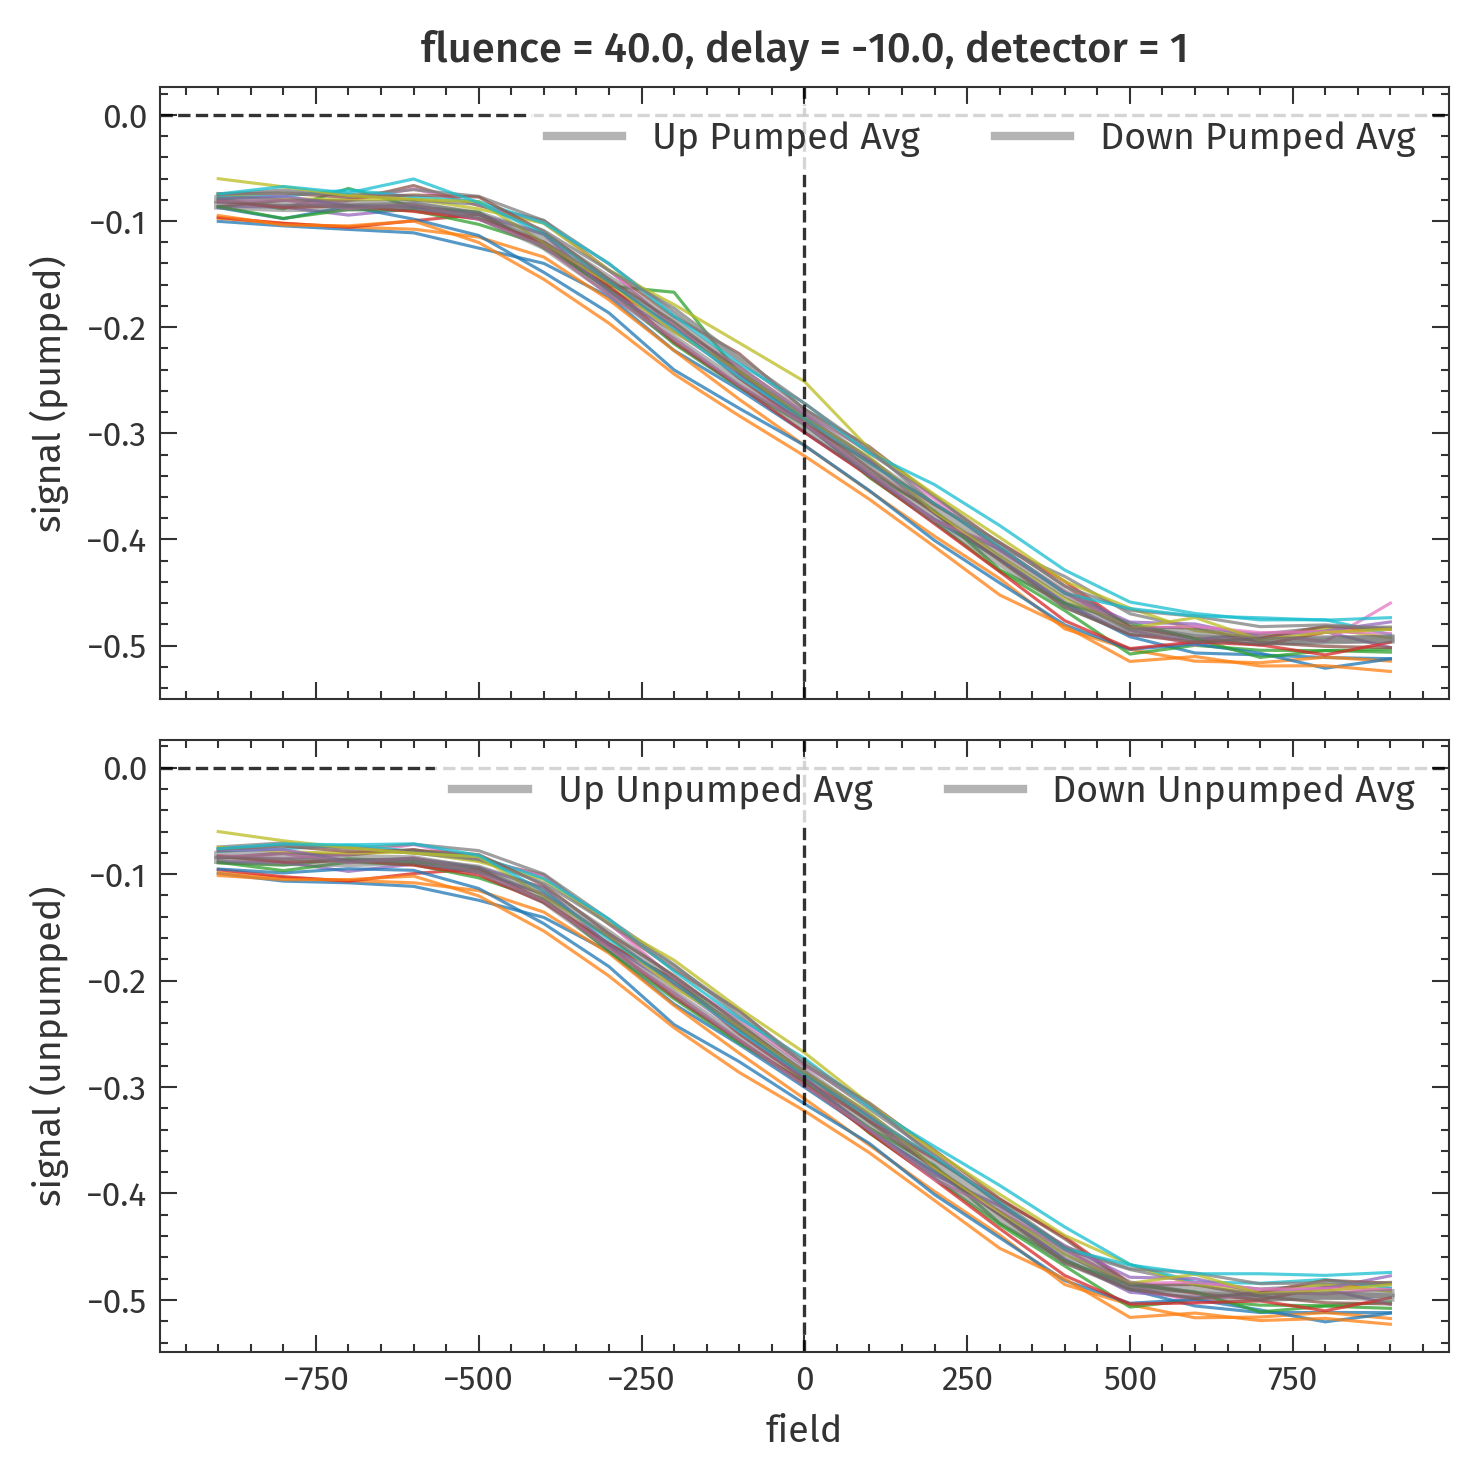

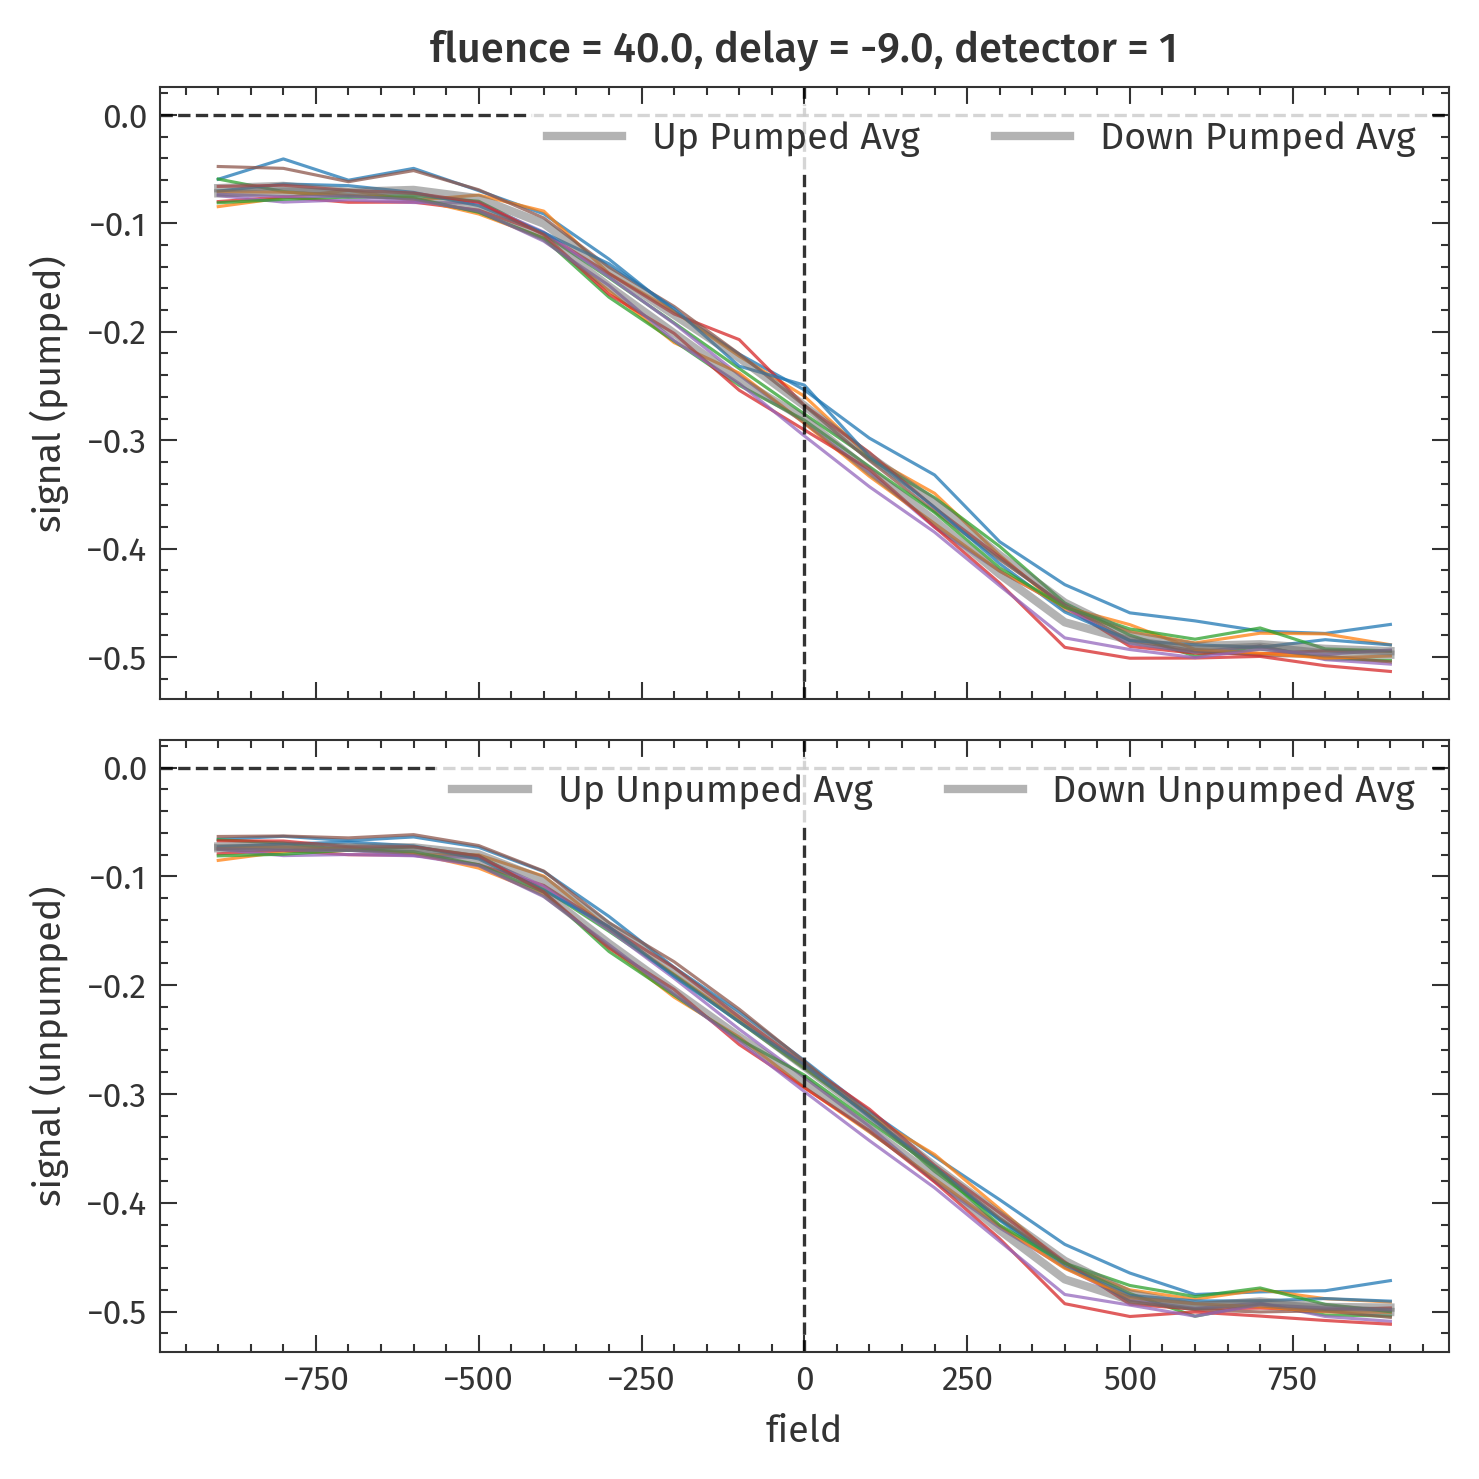

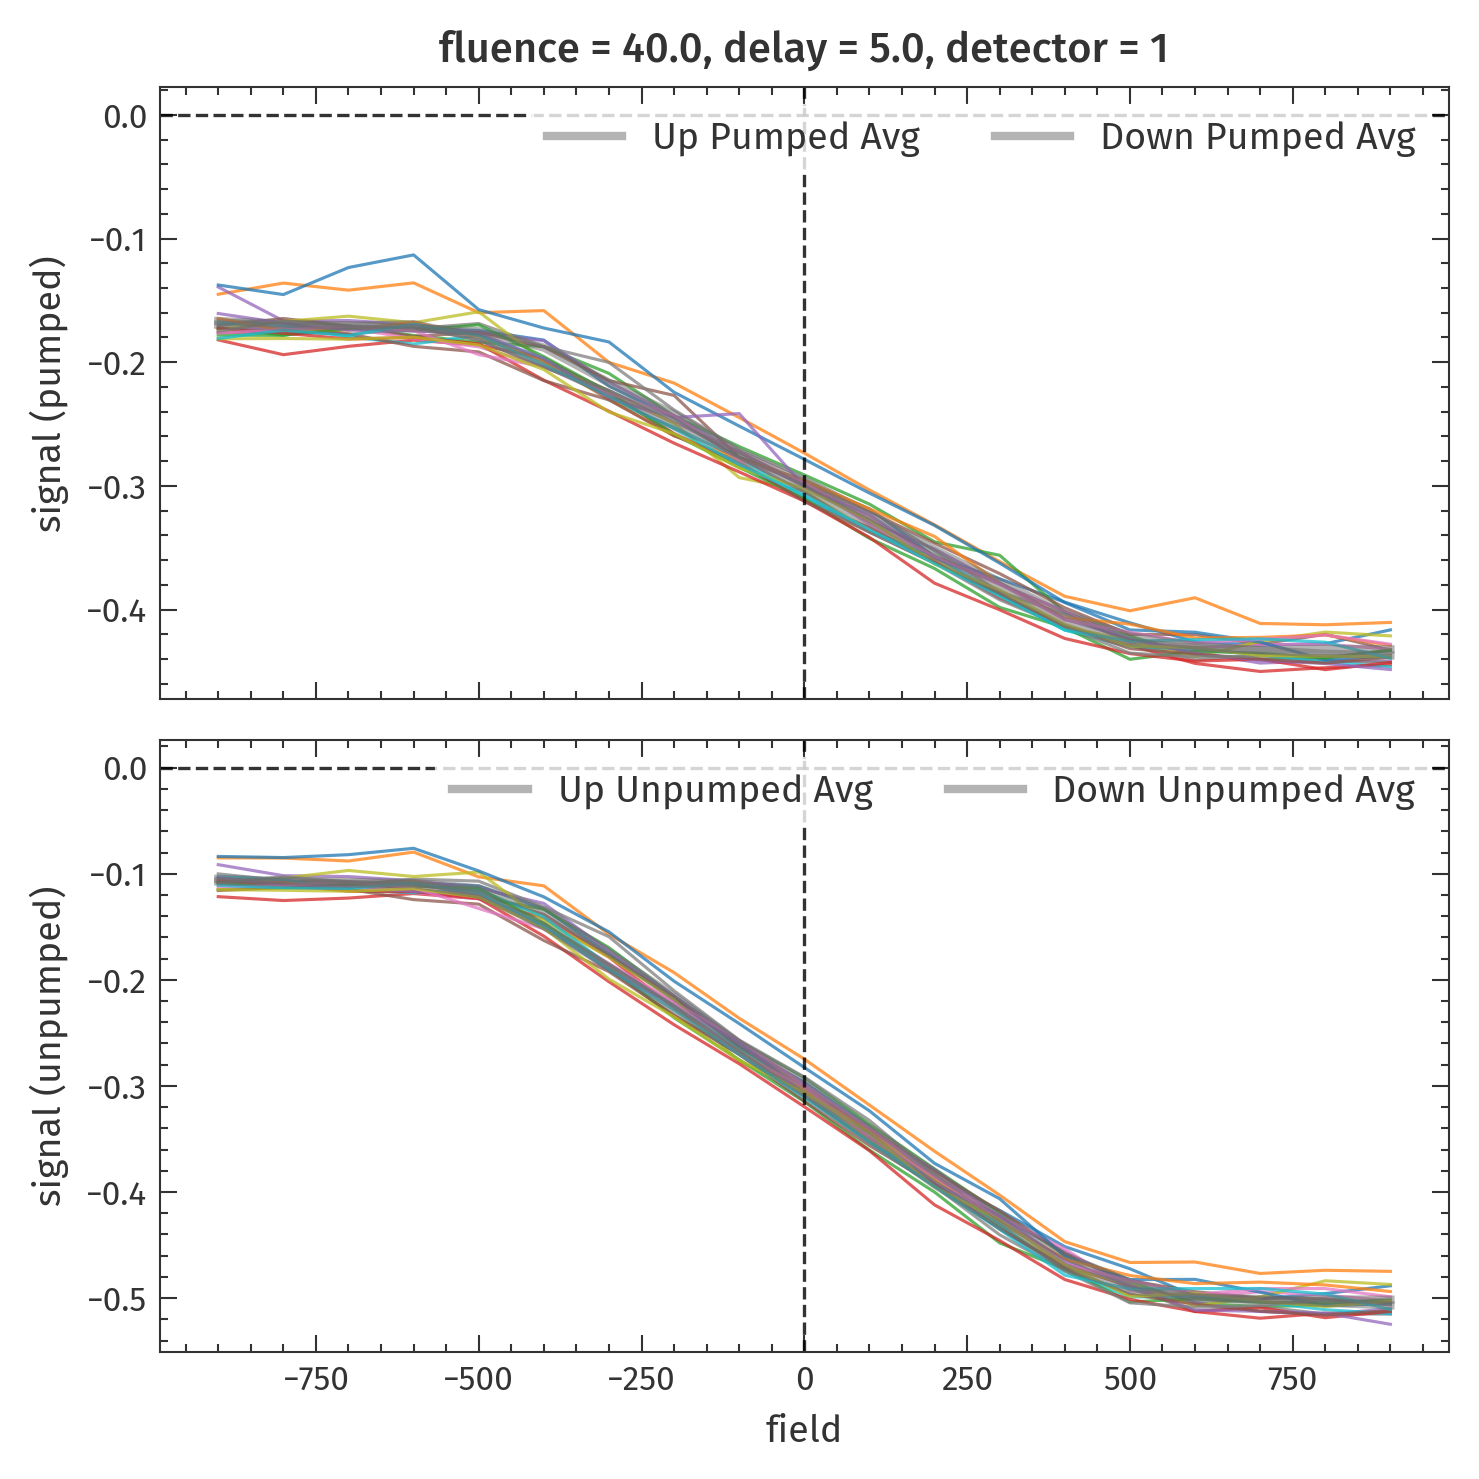

In [11]:
prop.plot_loopwise(16, detector_idx=1)

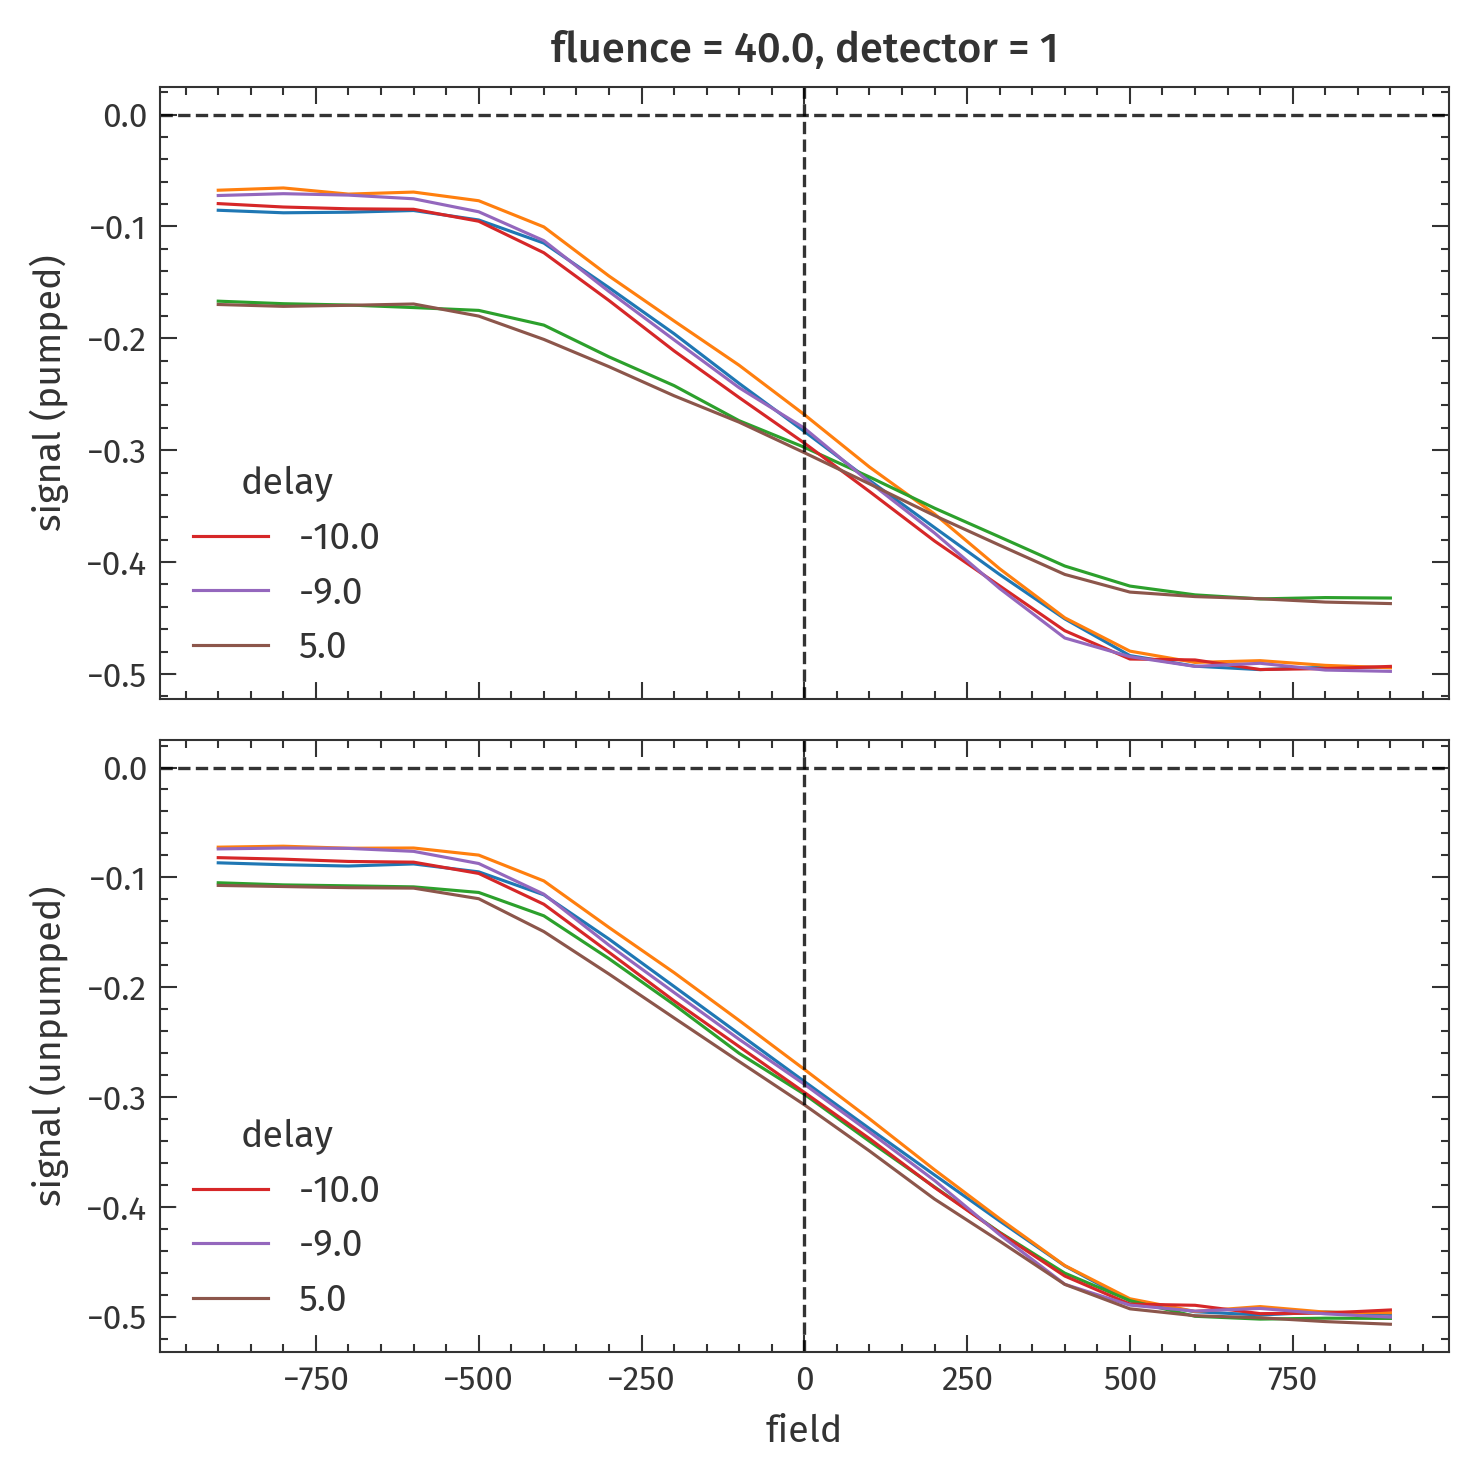

In [12]:
prop.plot_overview(16, detector_idx=1)

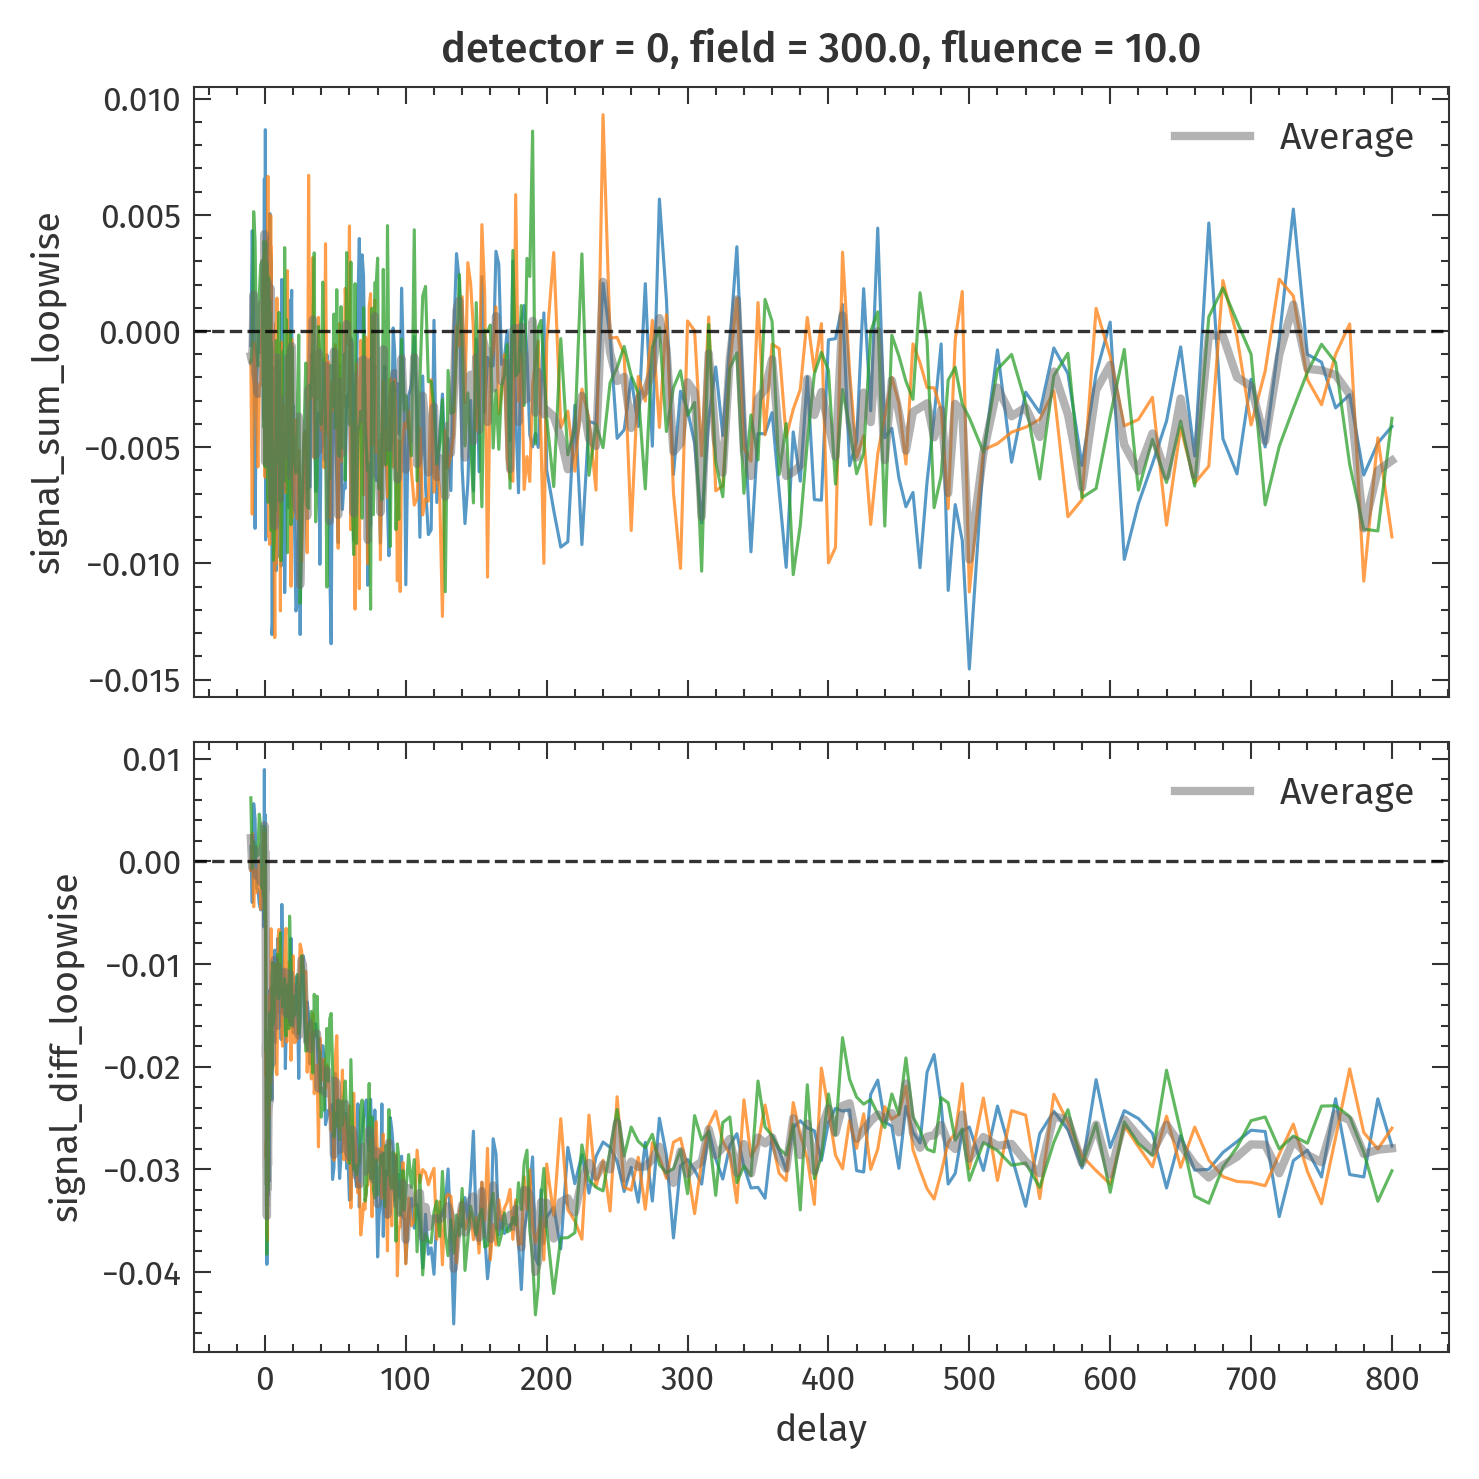

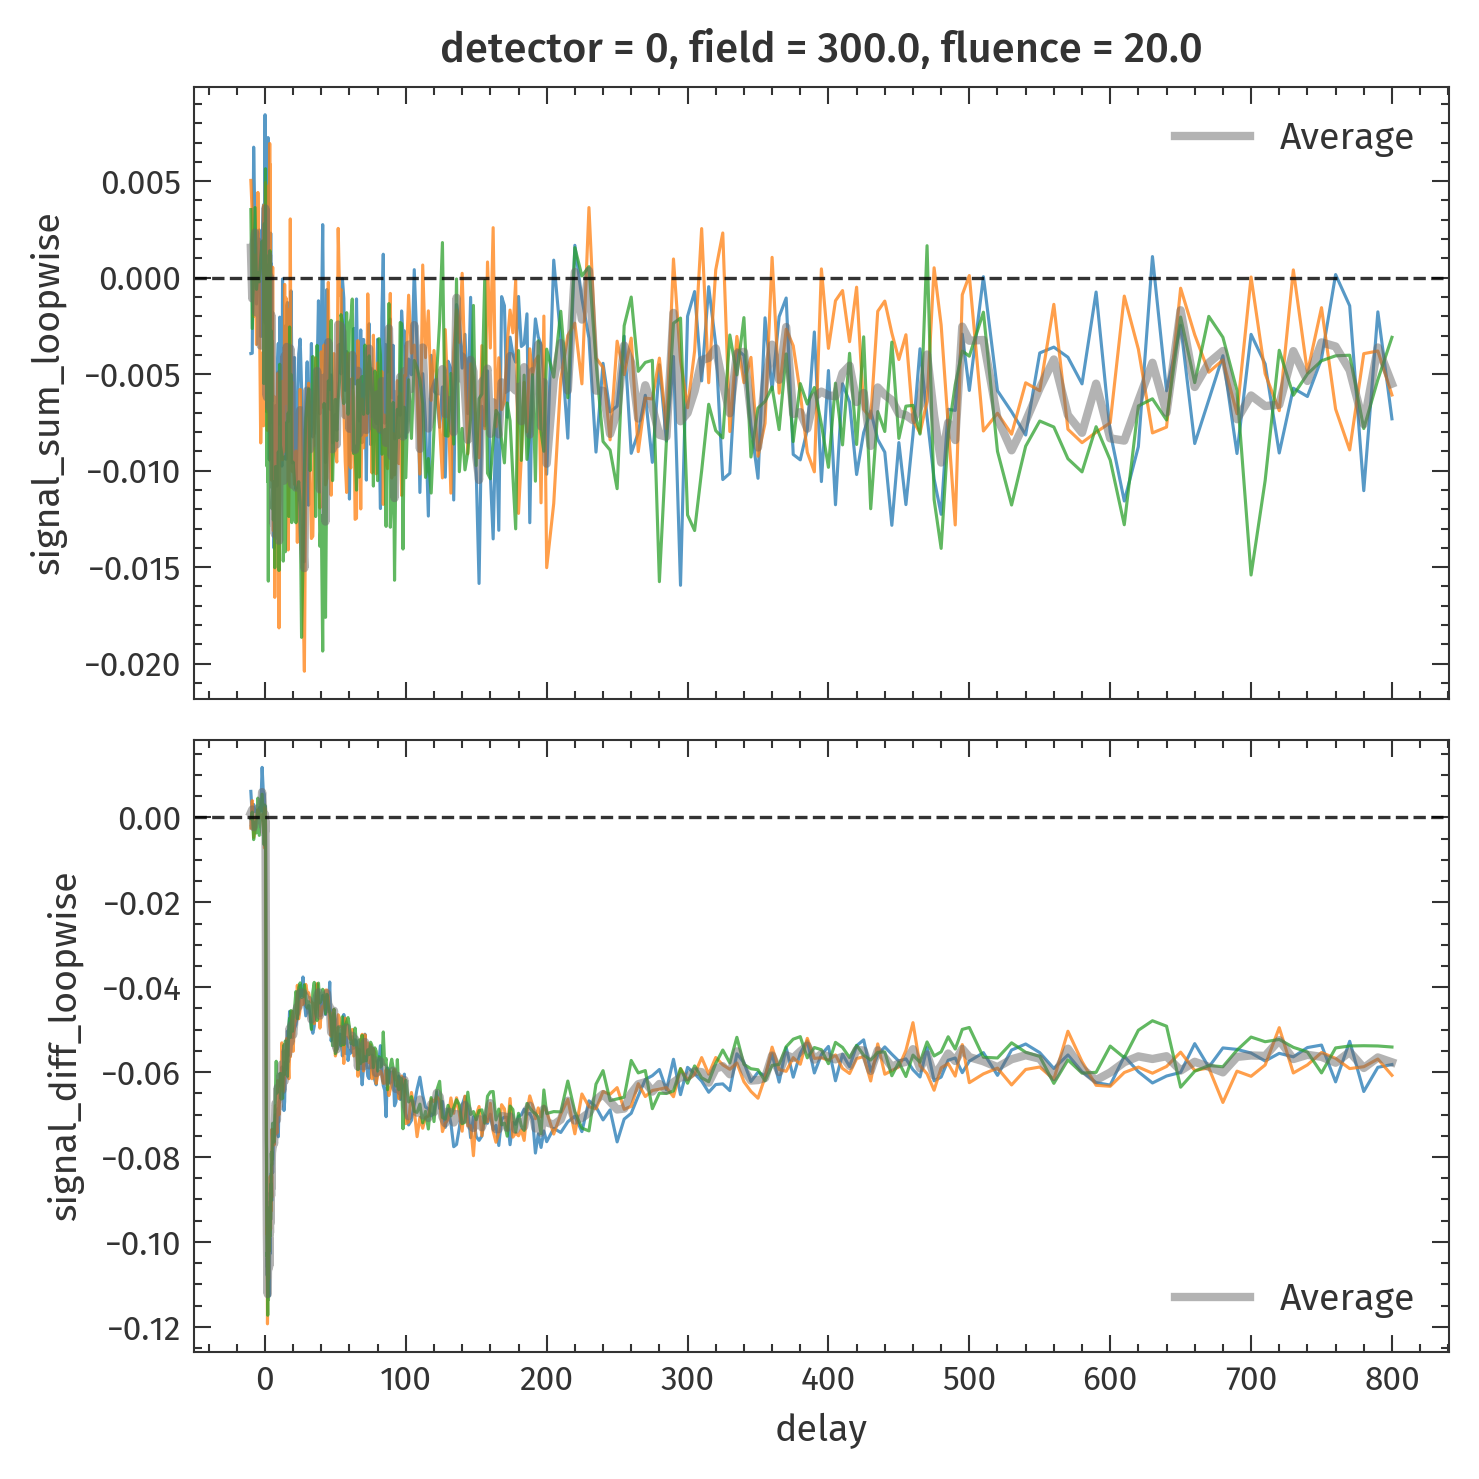

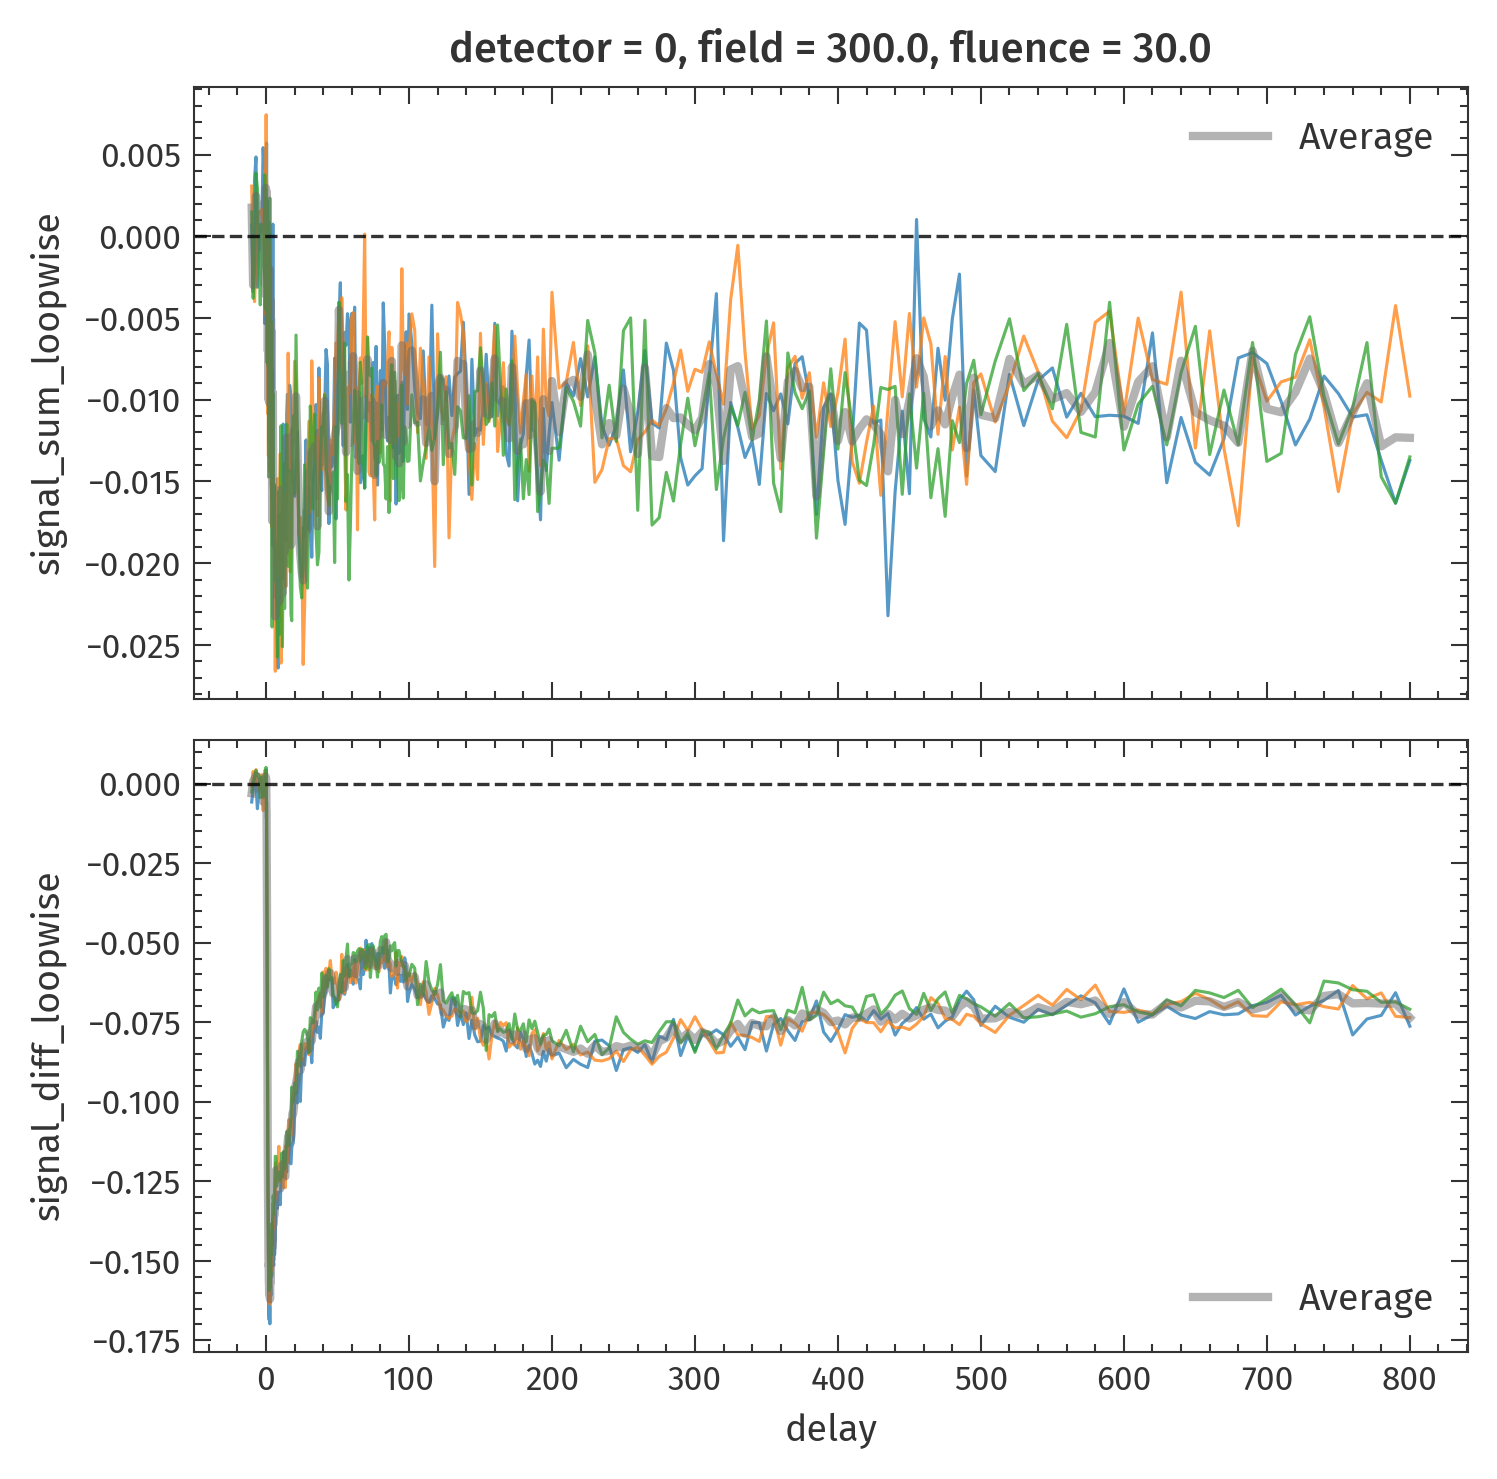

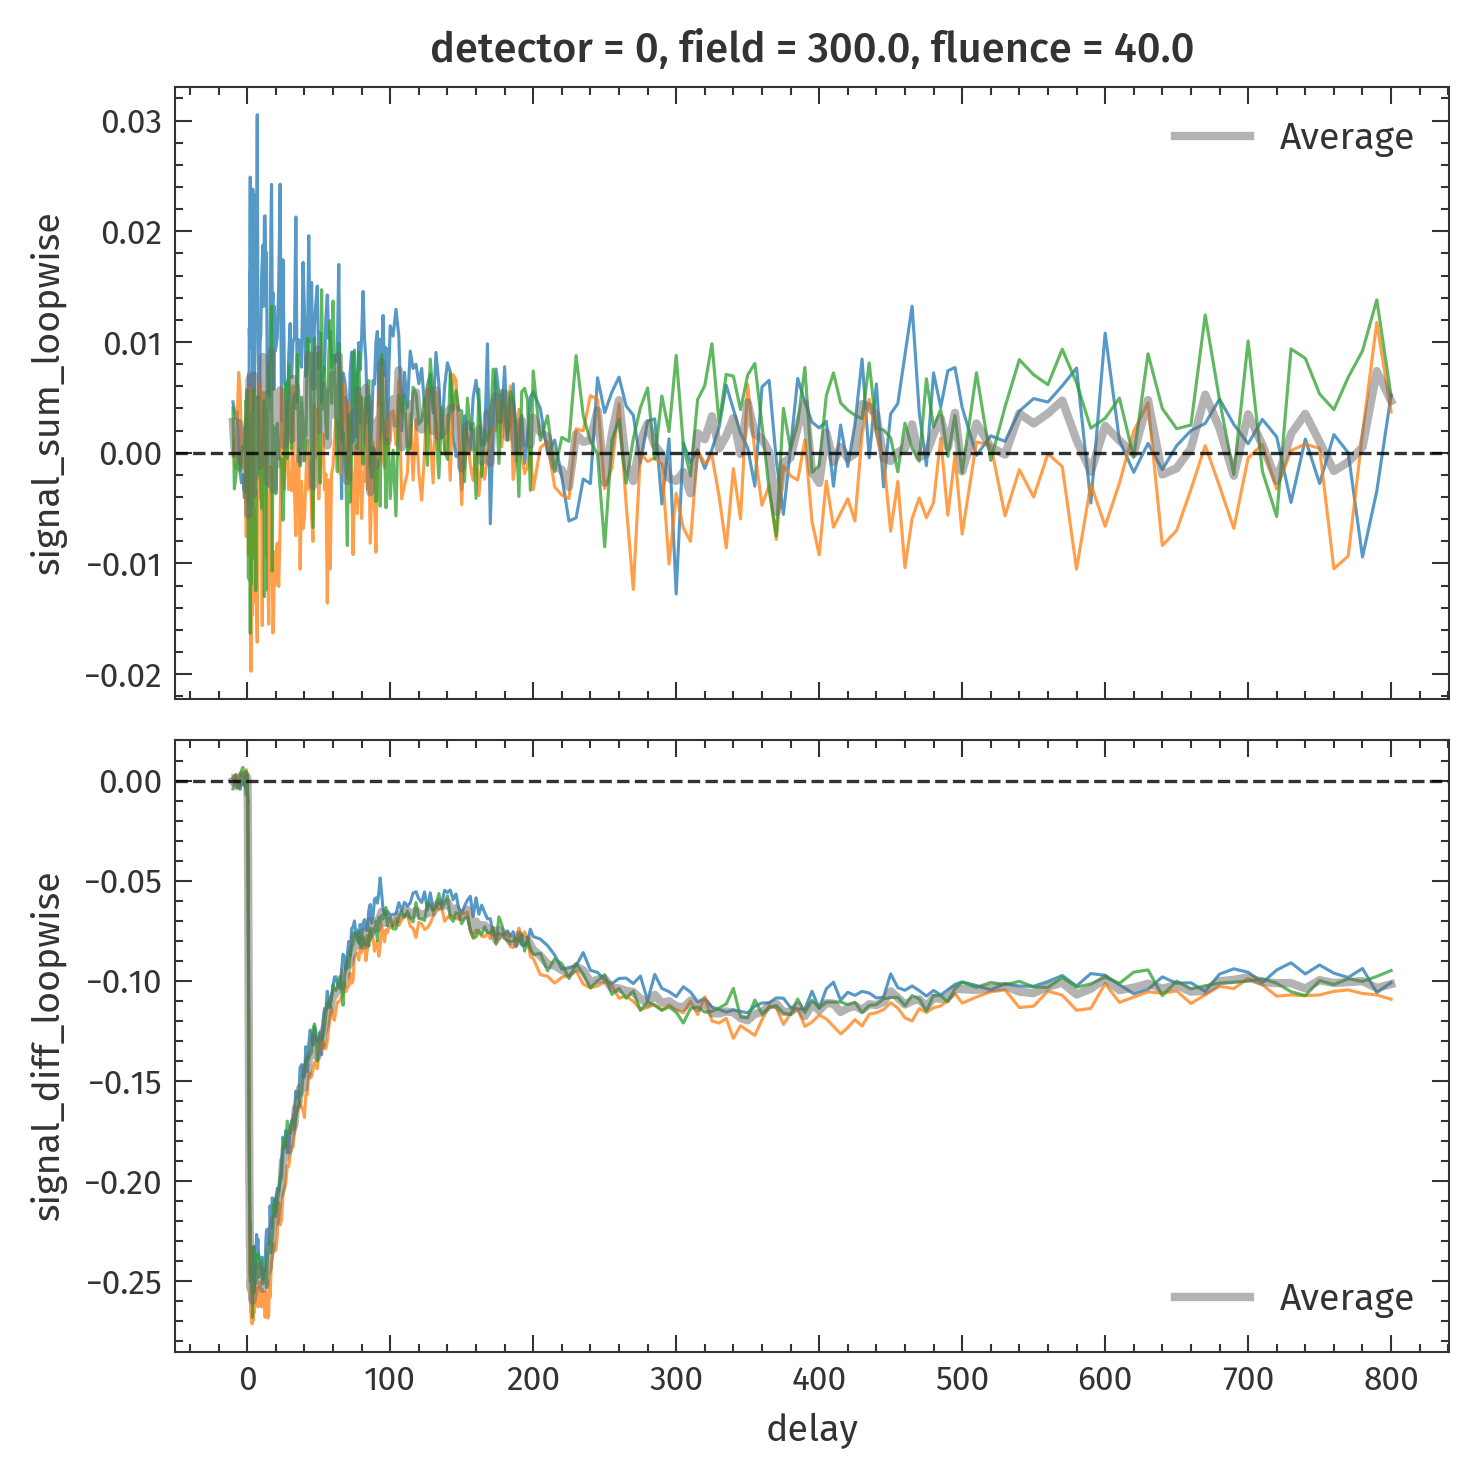

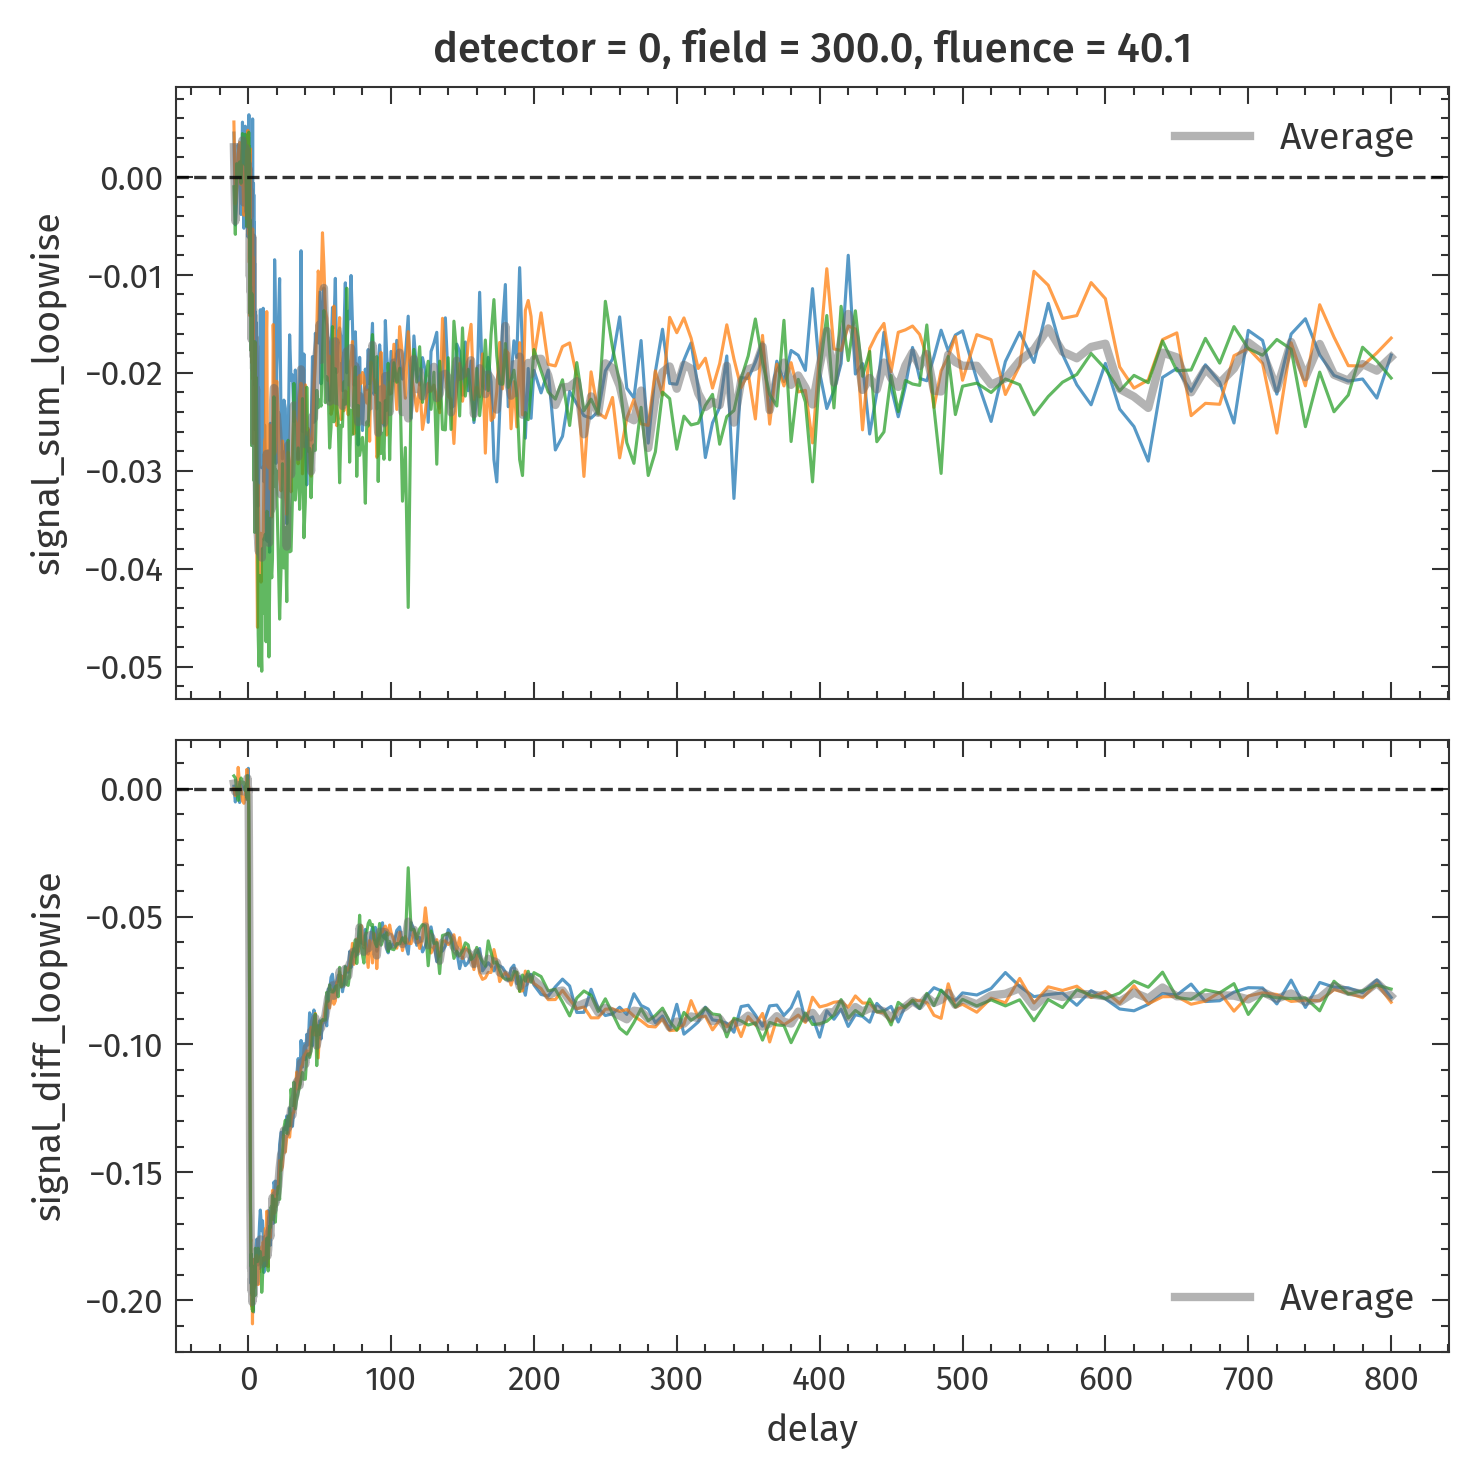

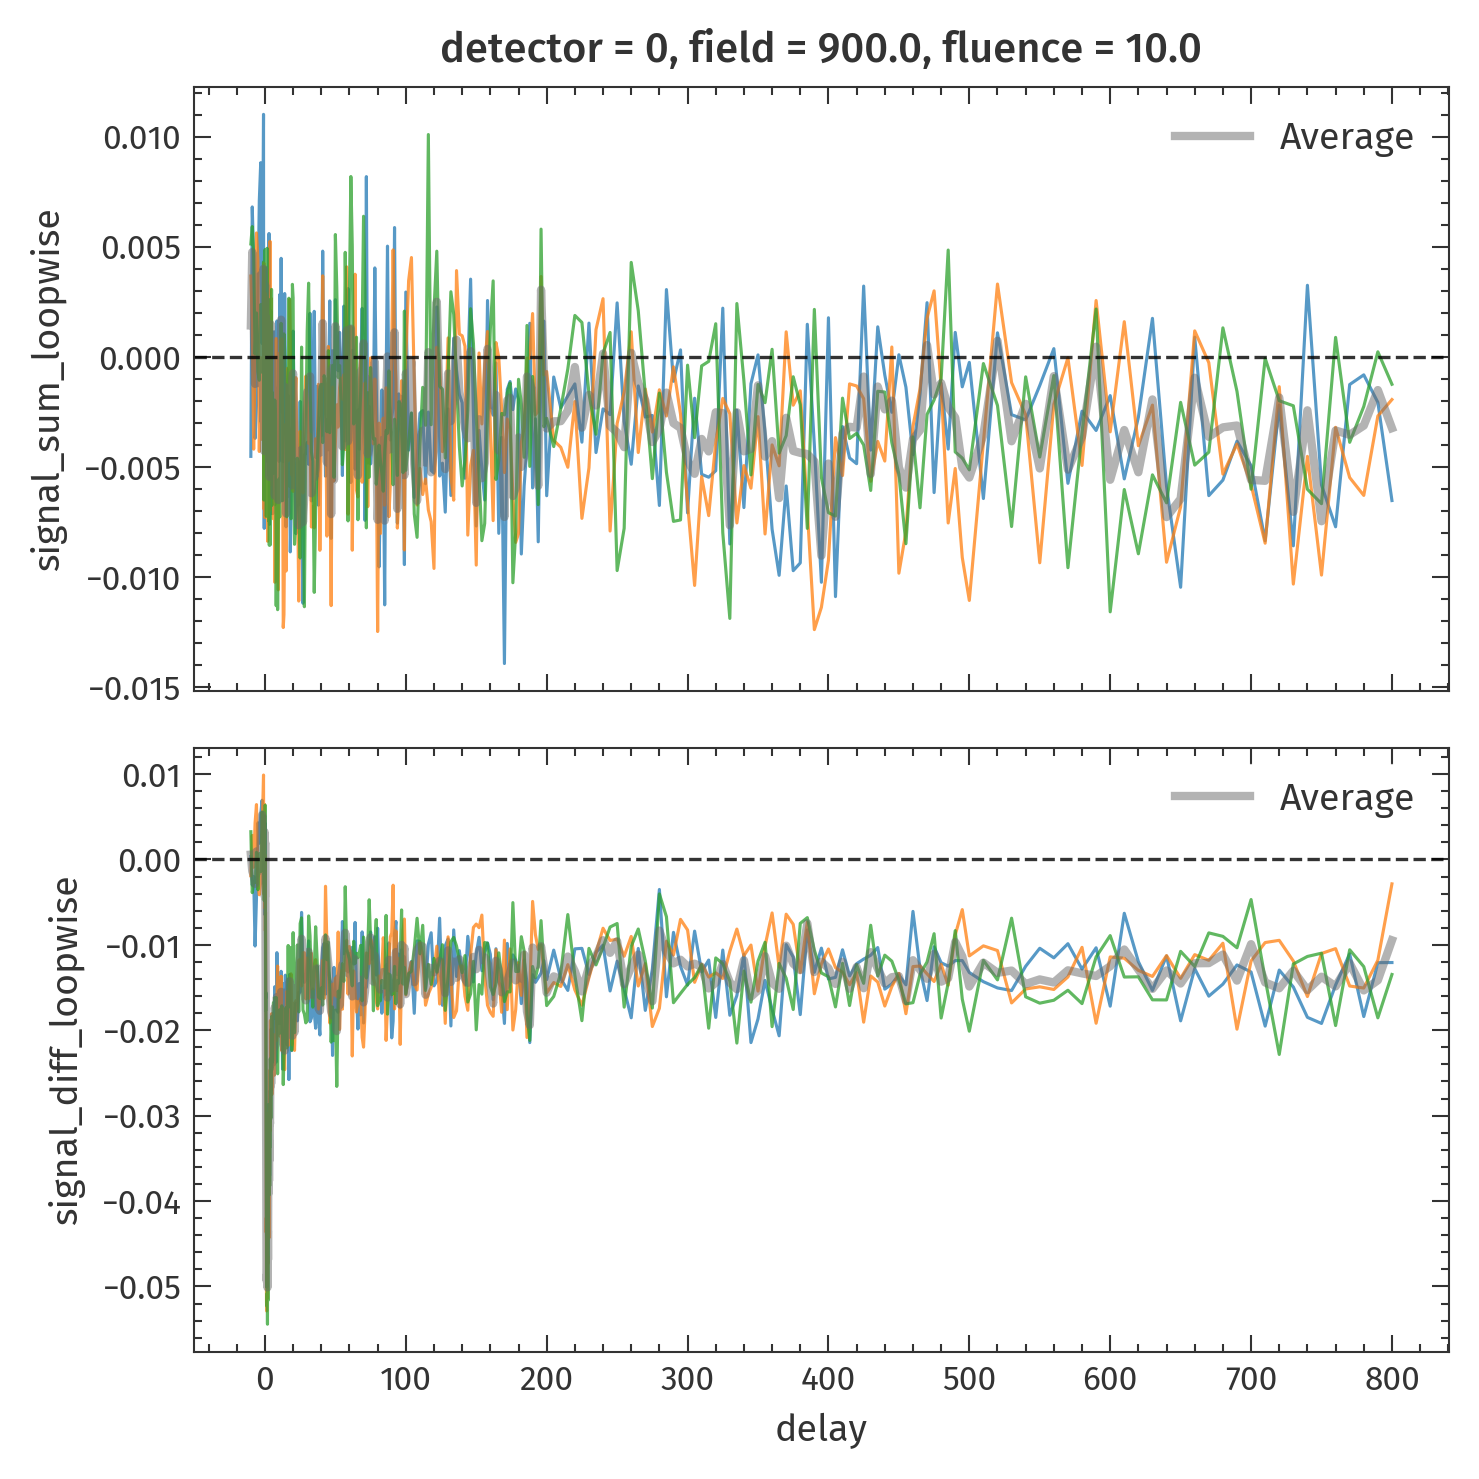

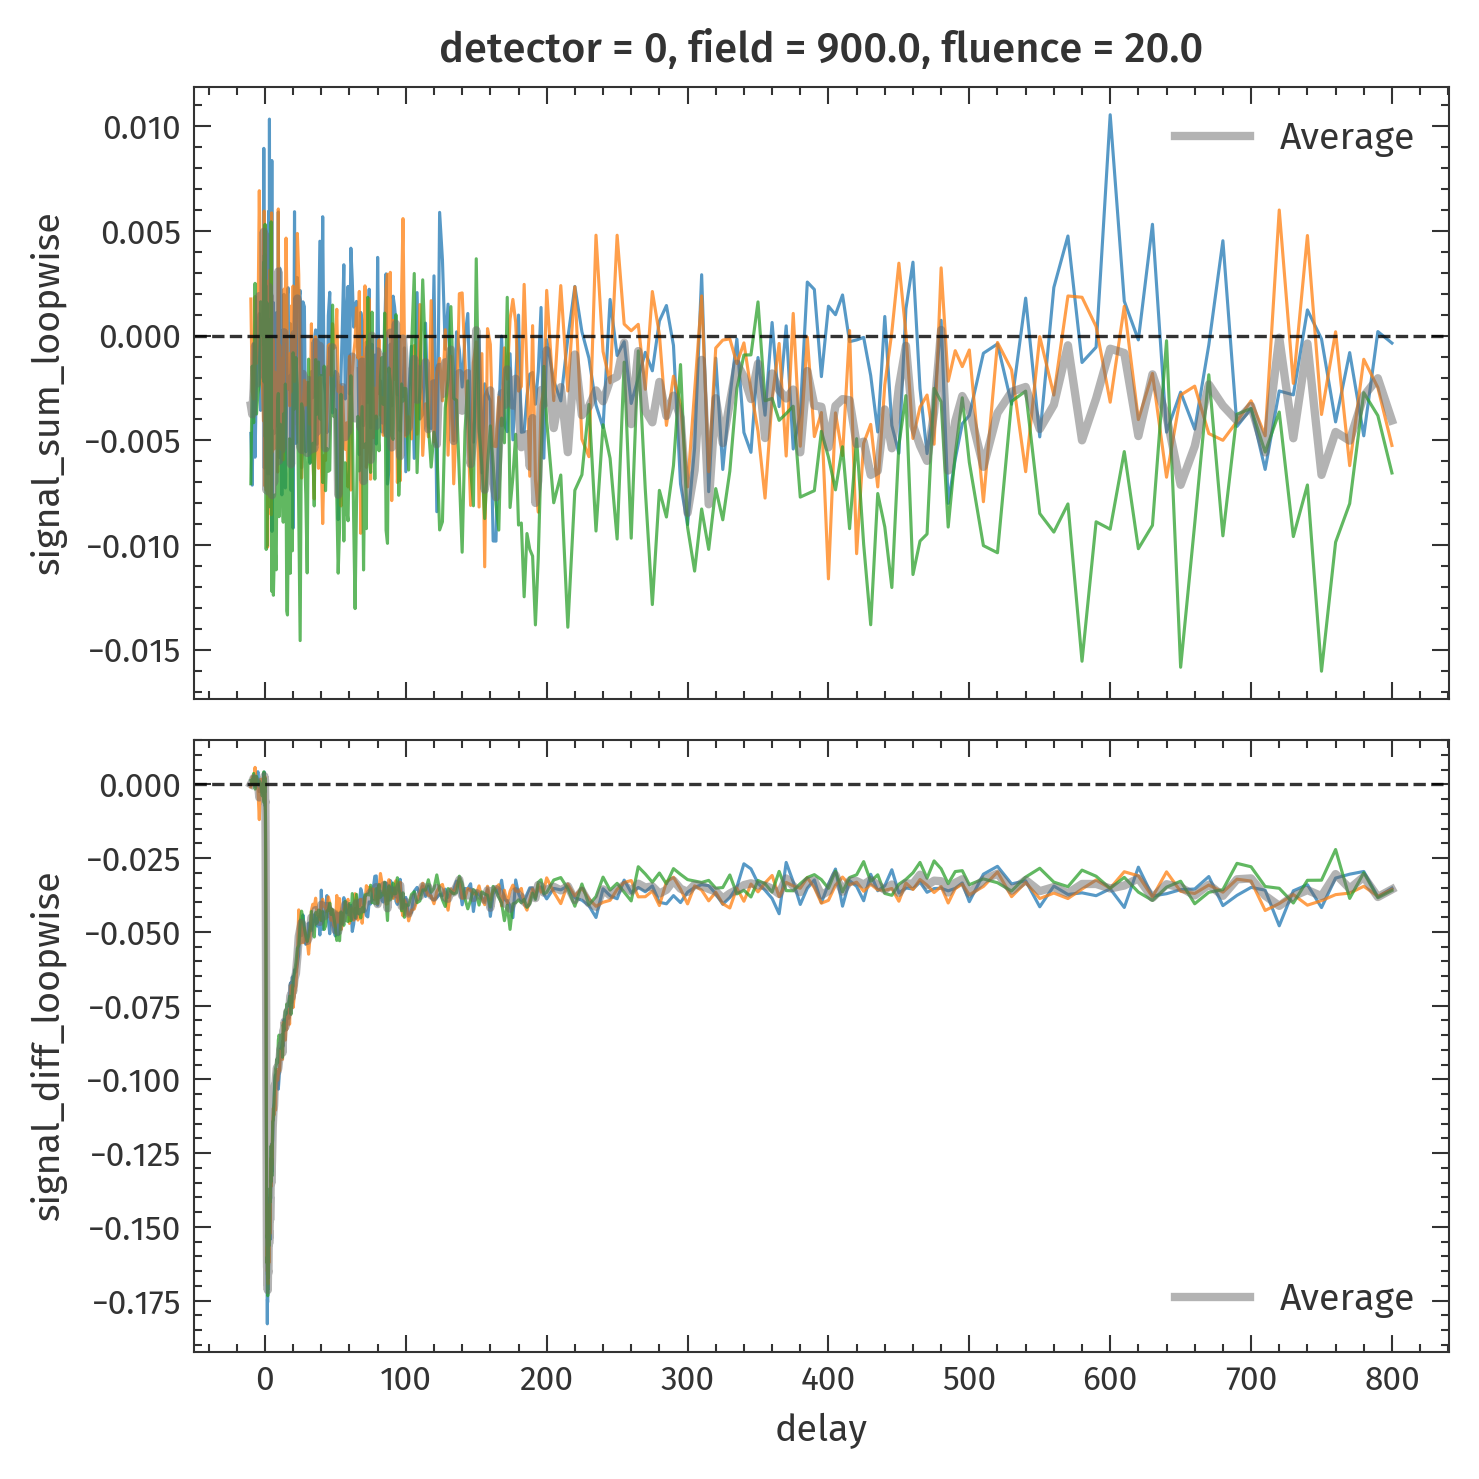

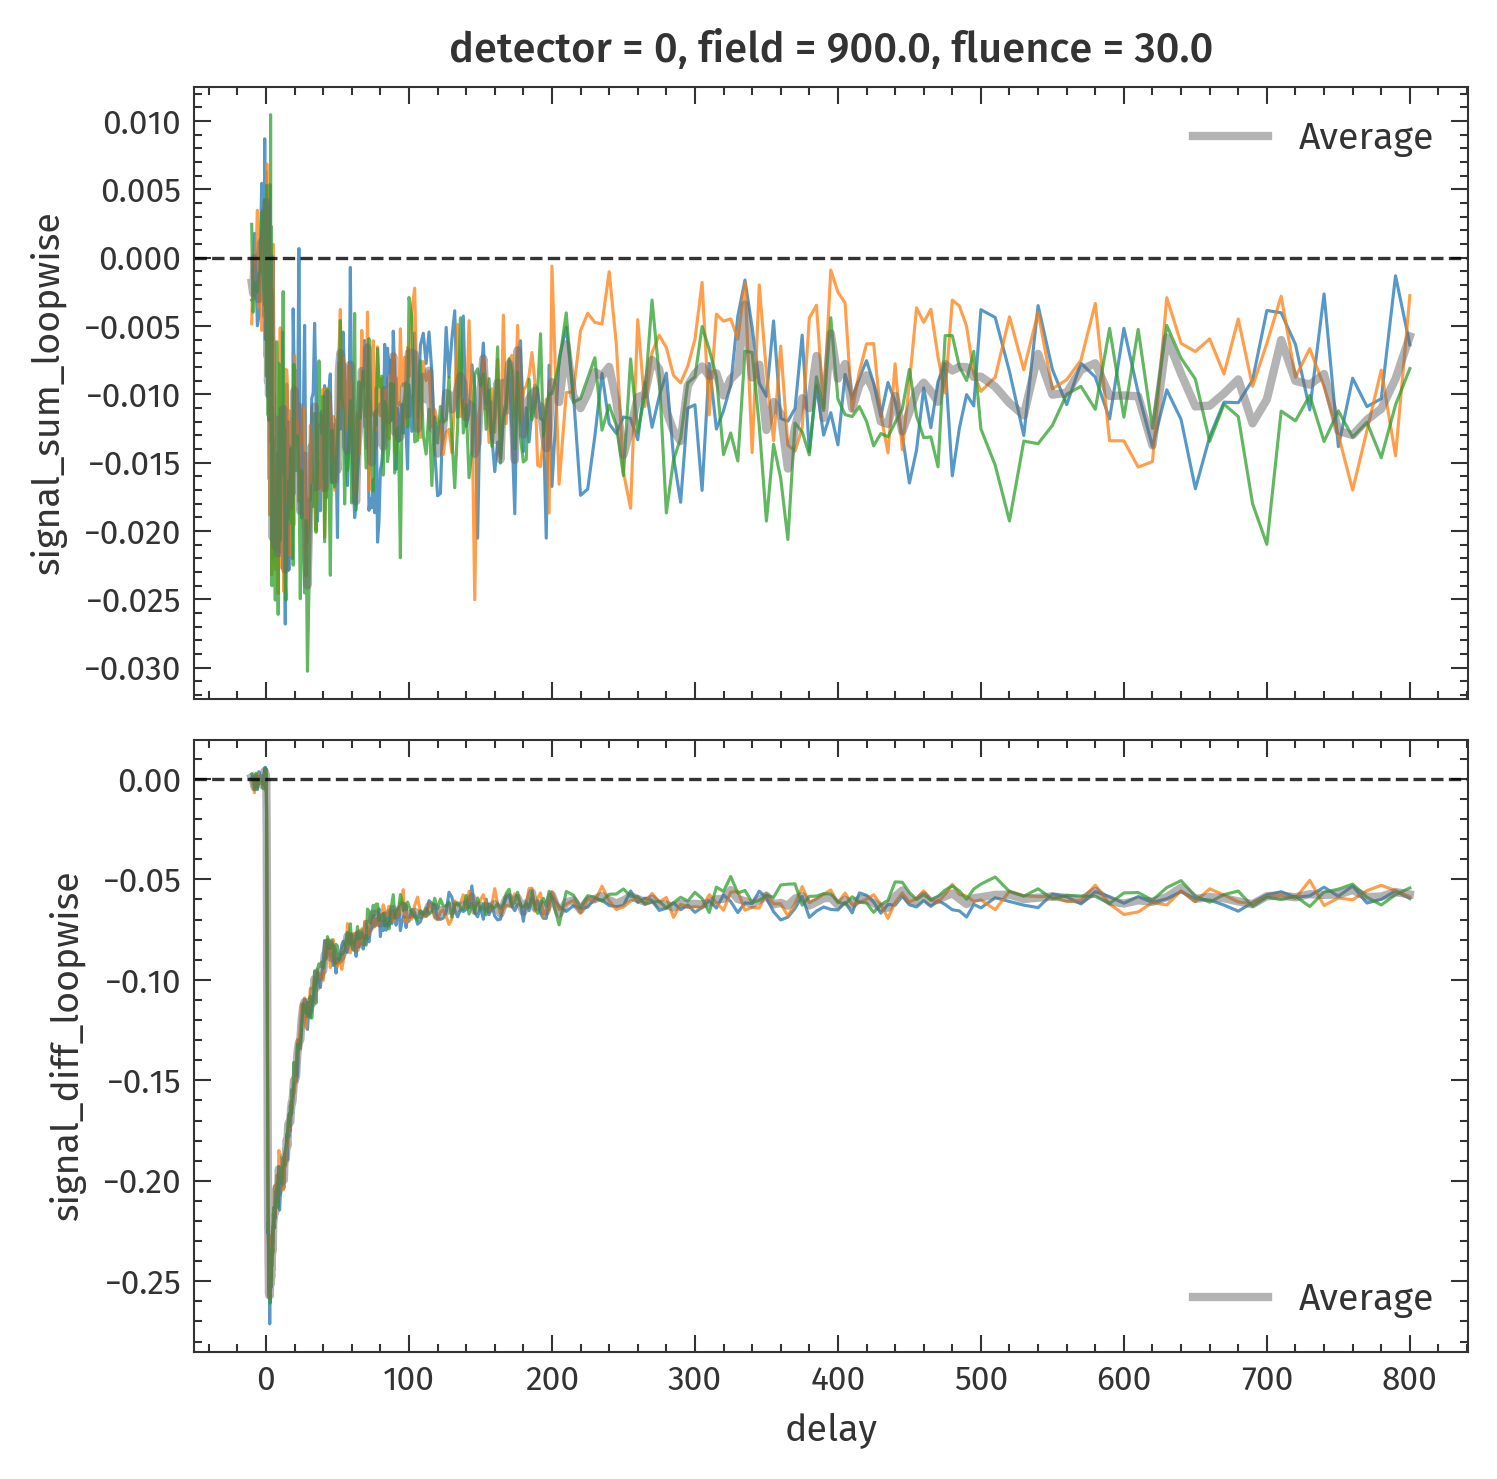

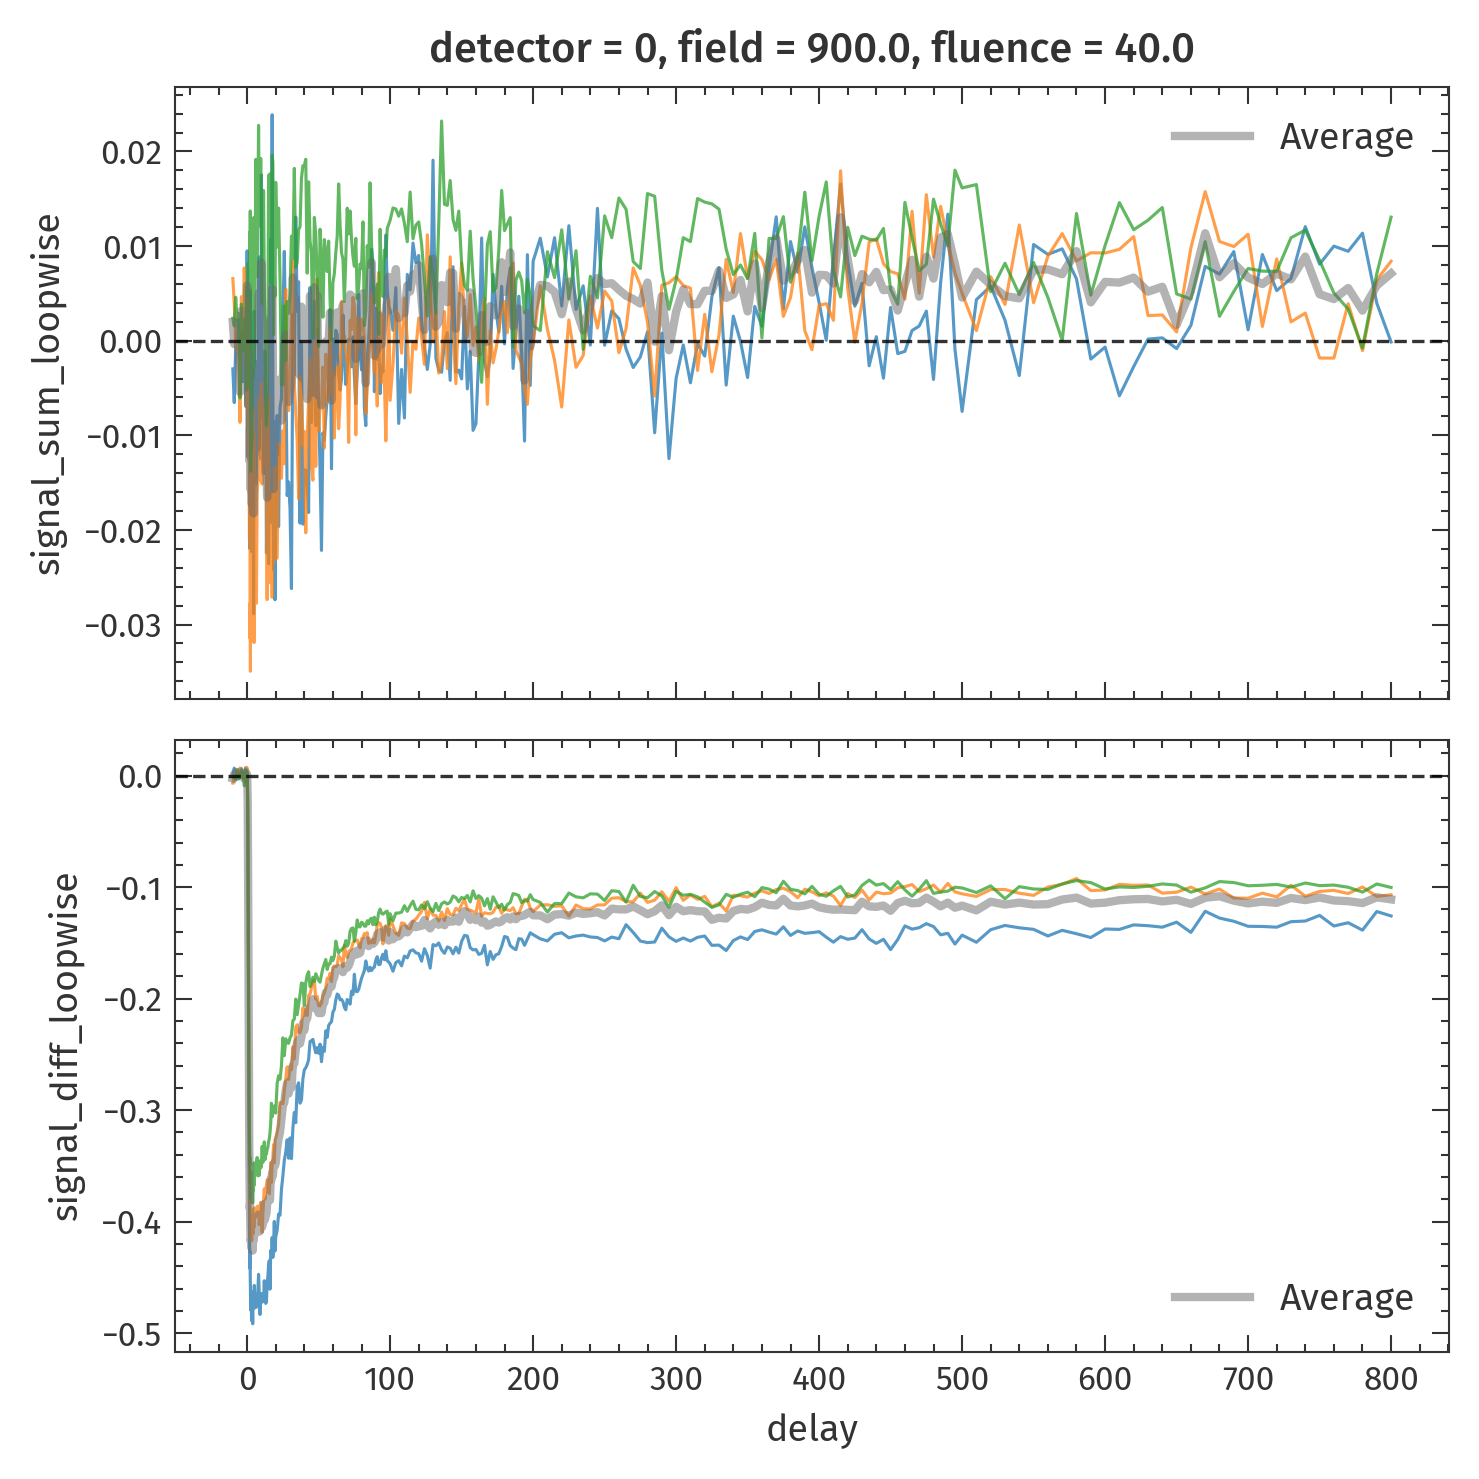

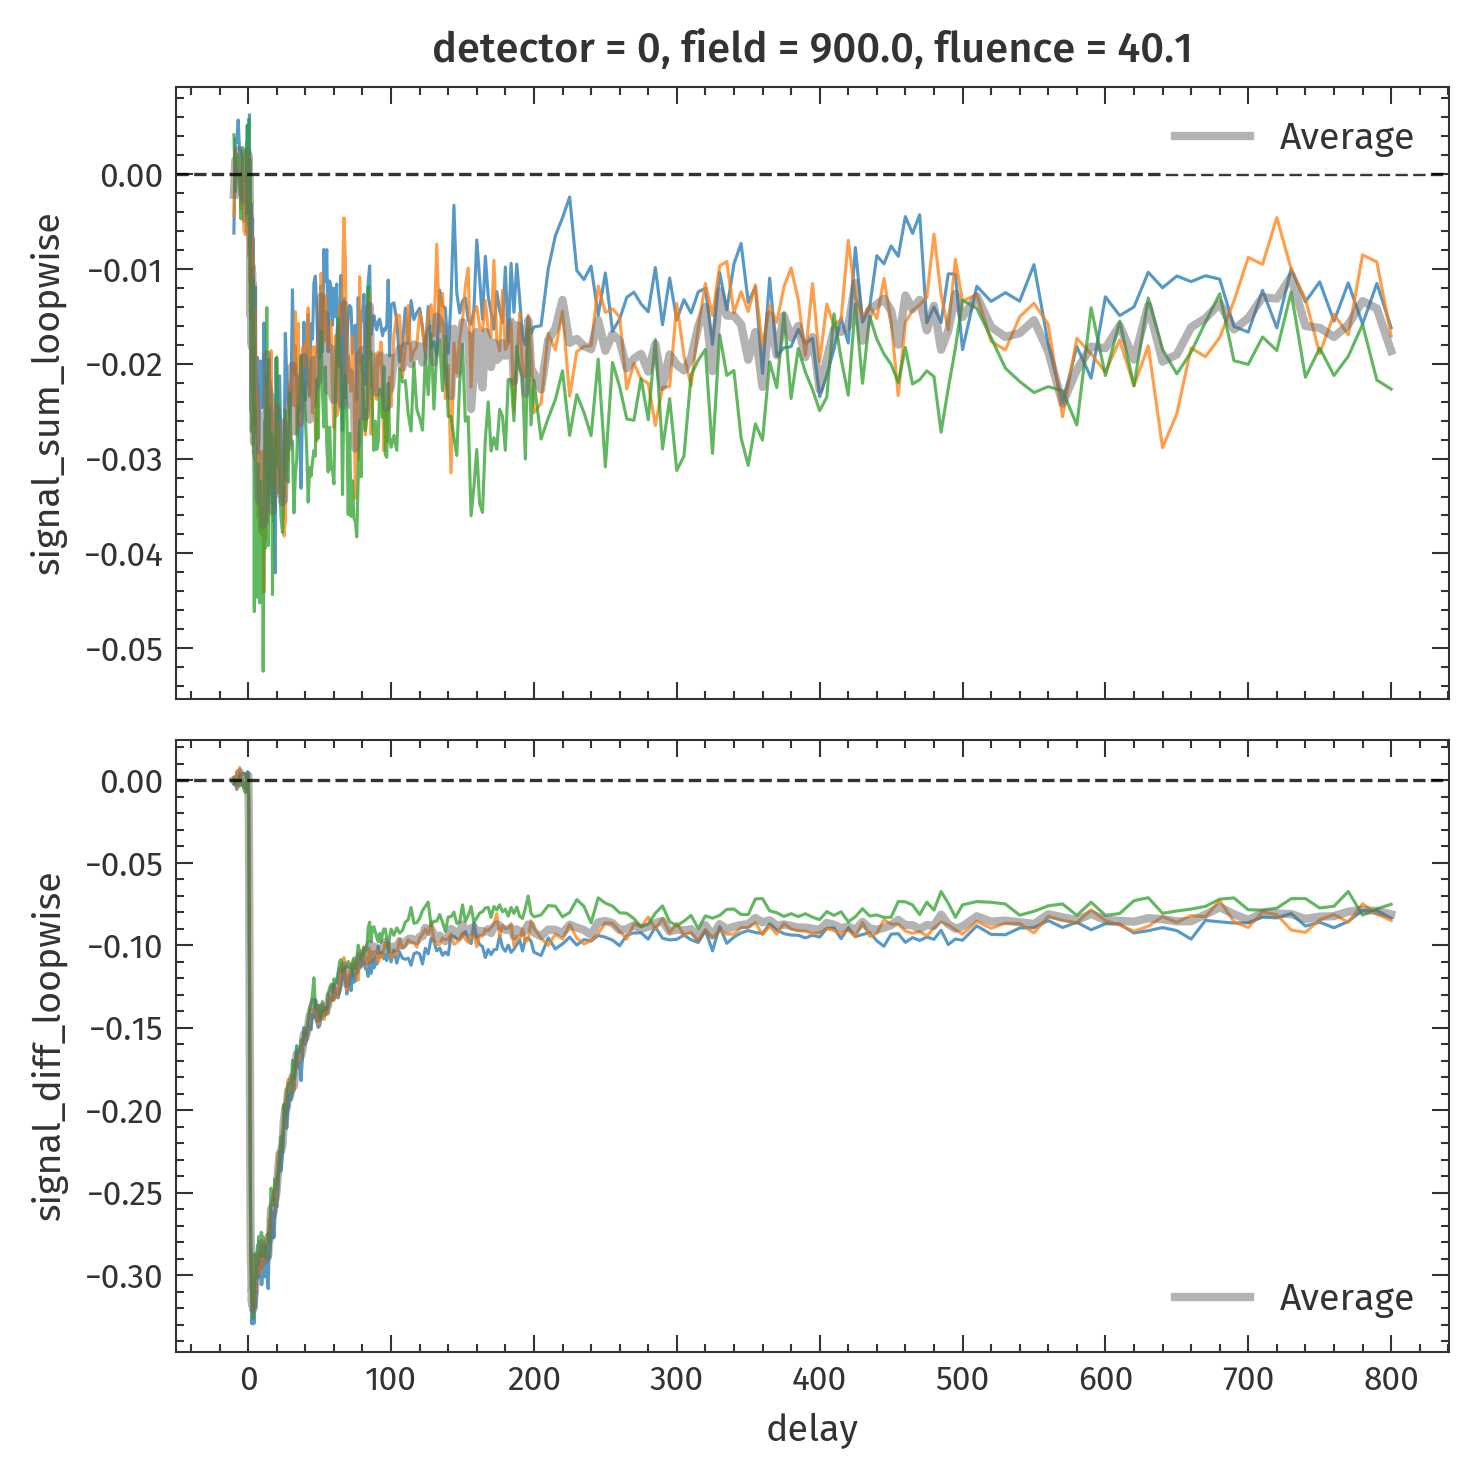

In [13]:
prop.plot_loopwise(17, detector_idx=0)

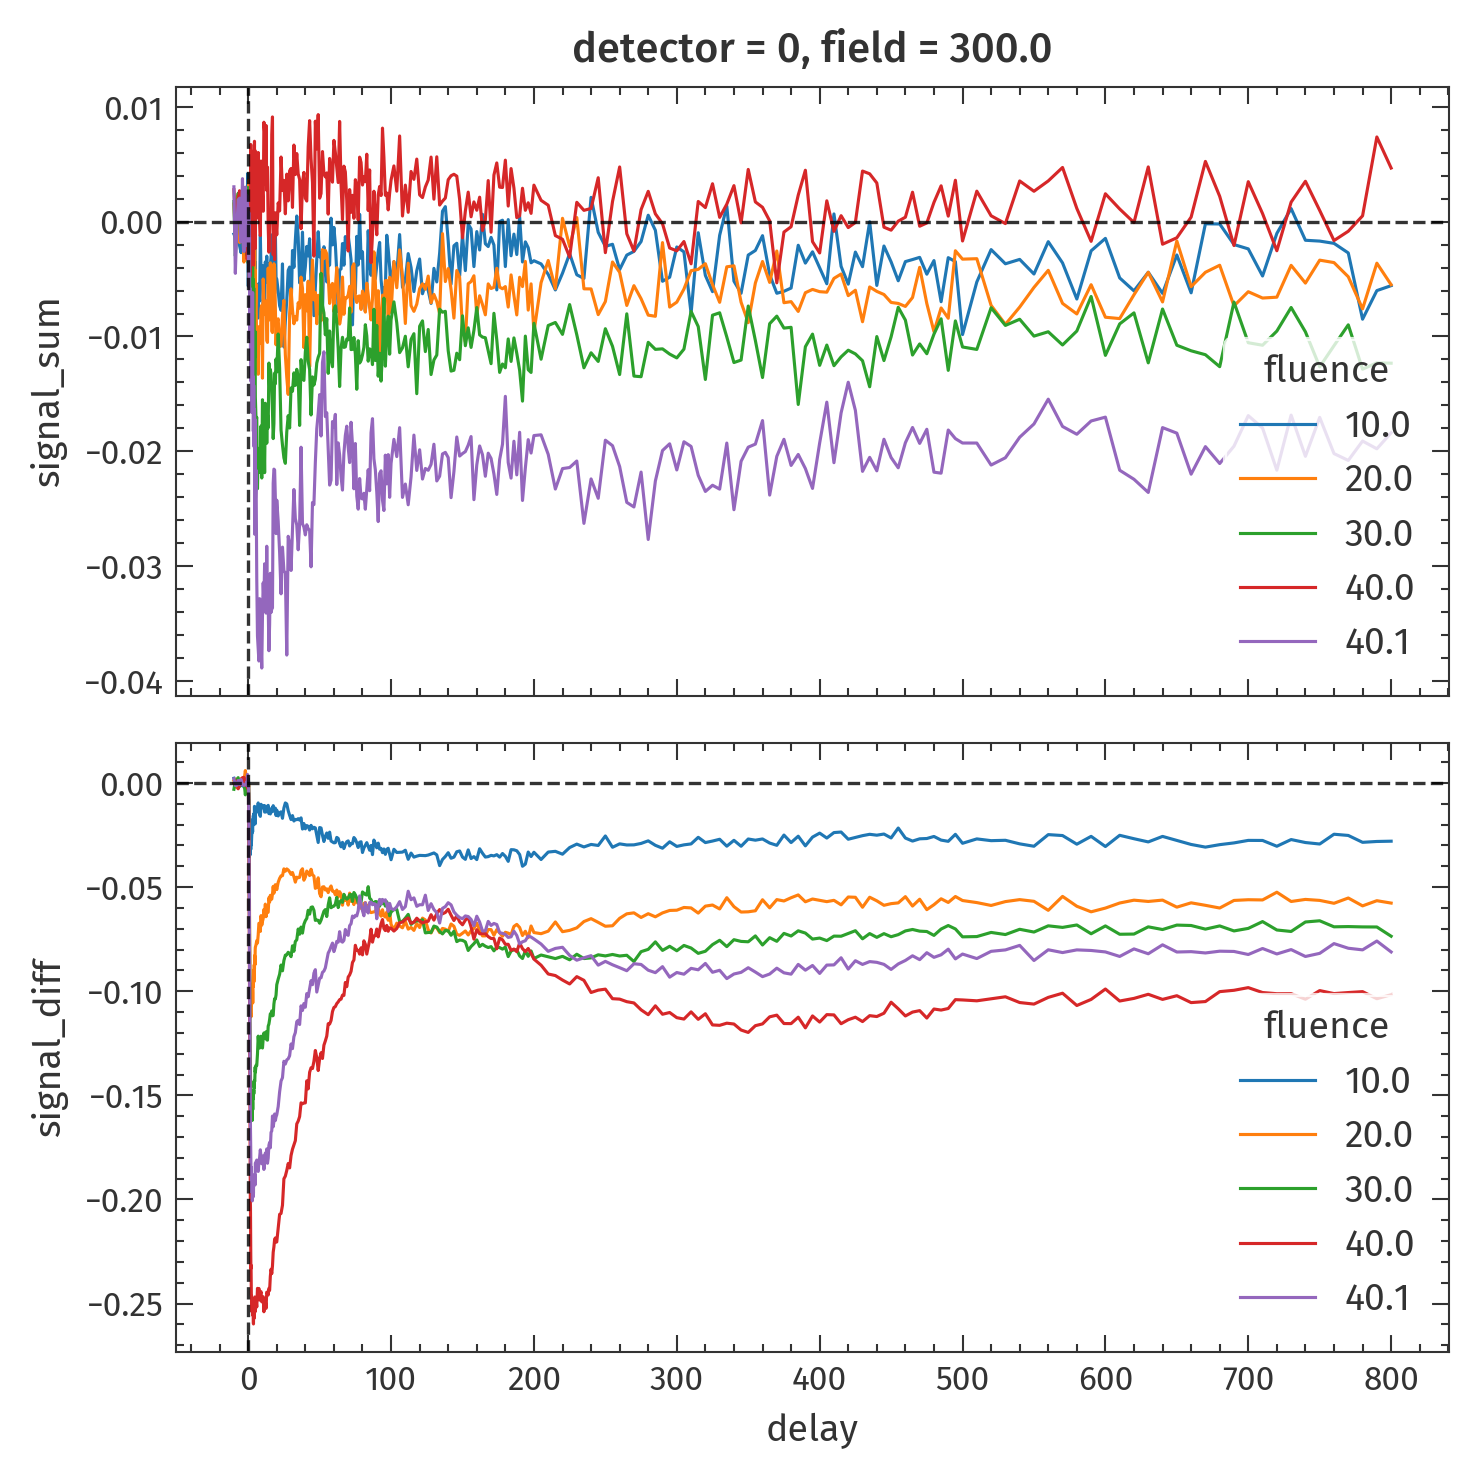

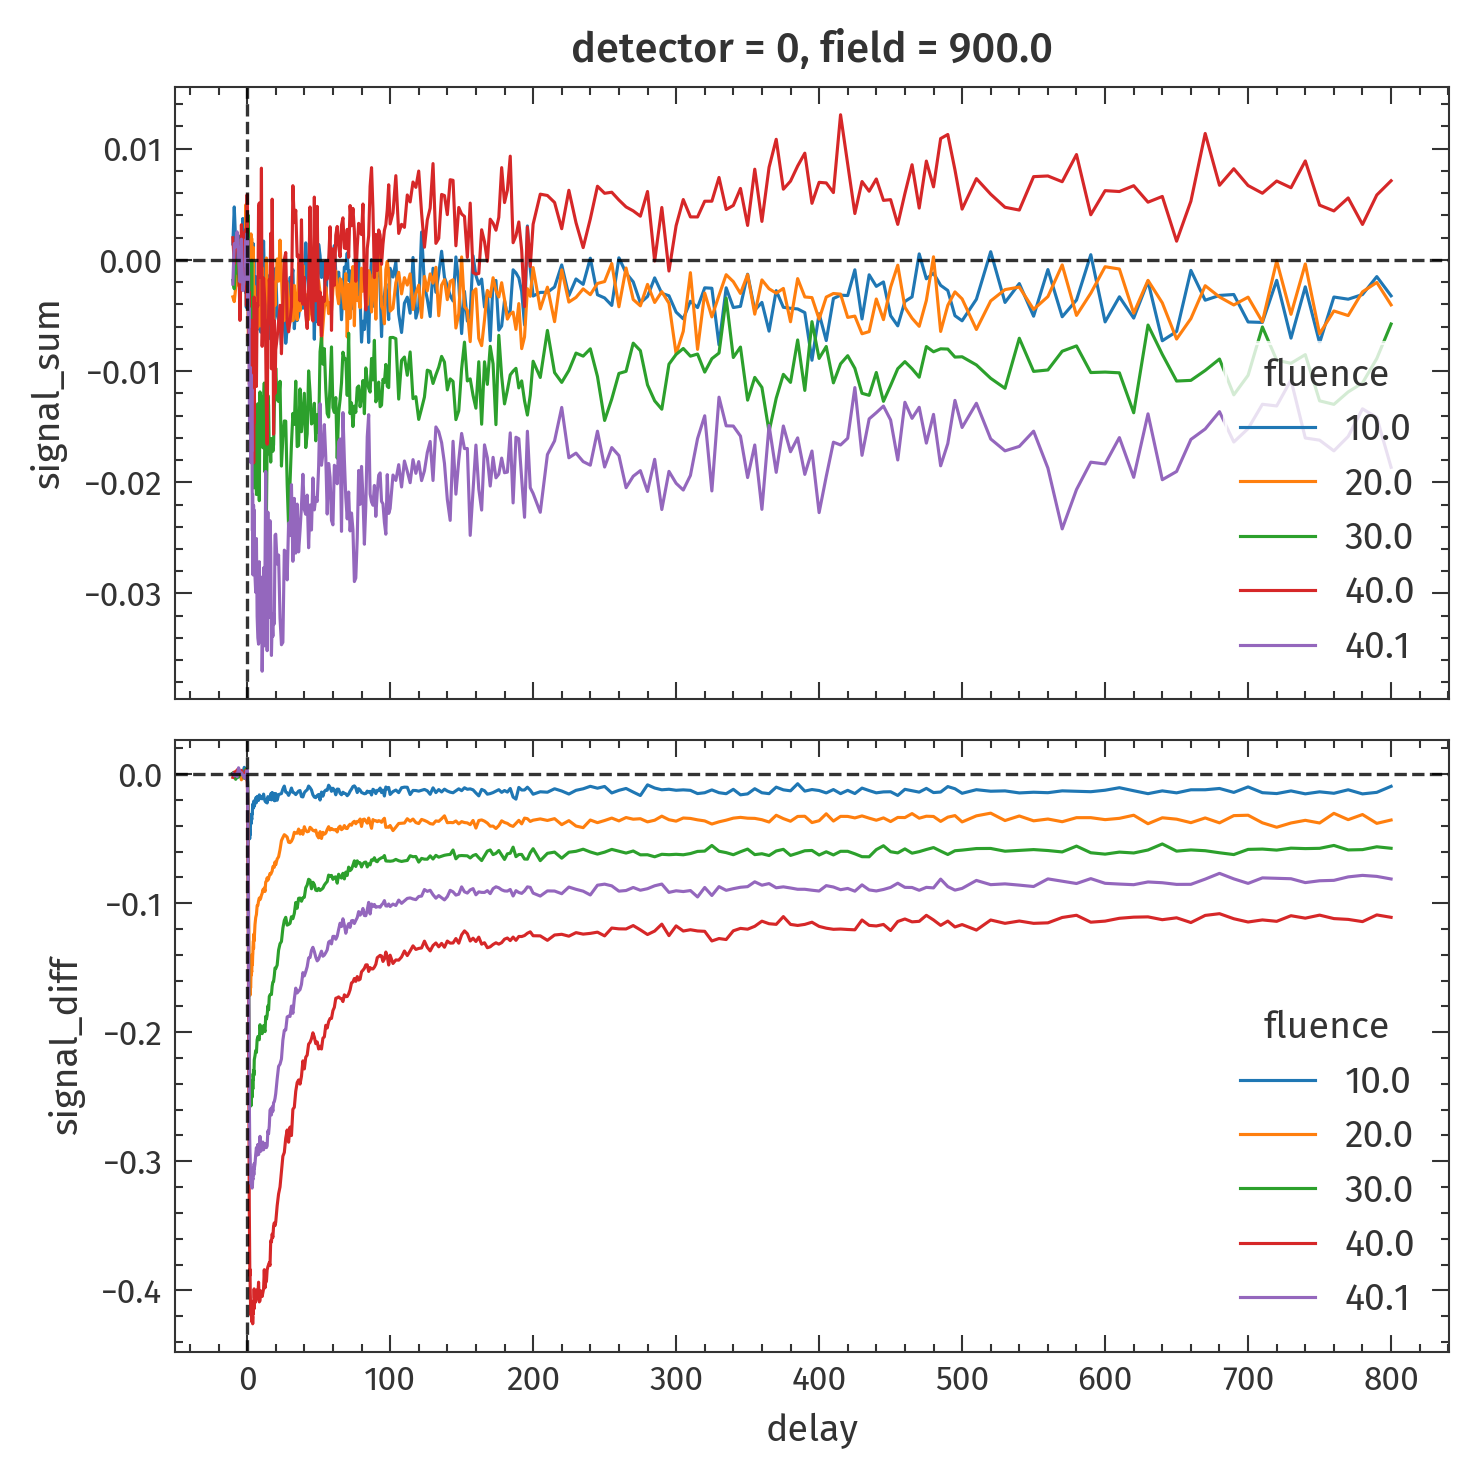

In [14]:
prop.plot_overview(17, detector_idx=0)

Similar plots can be built manually too, of course:

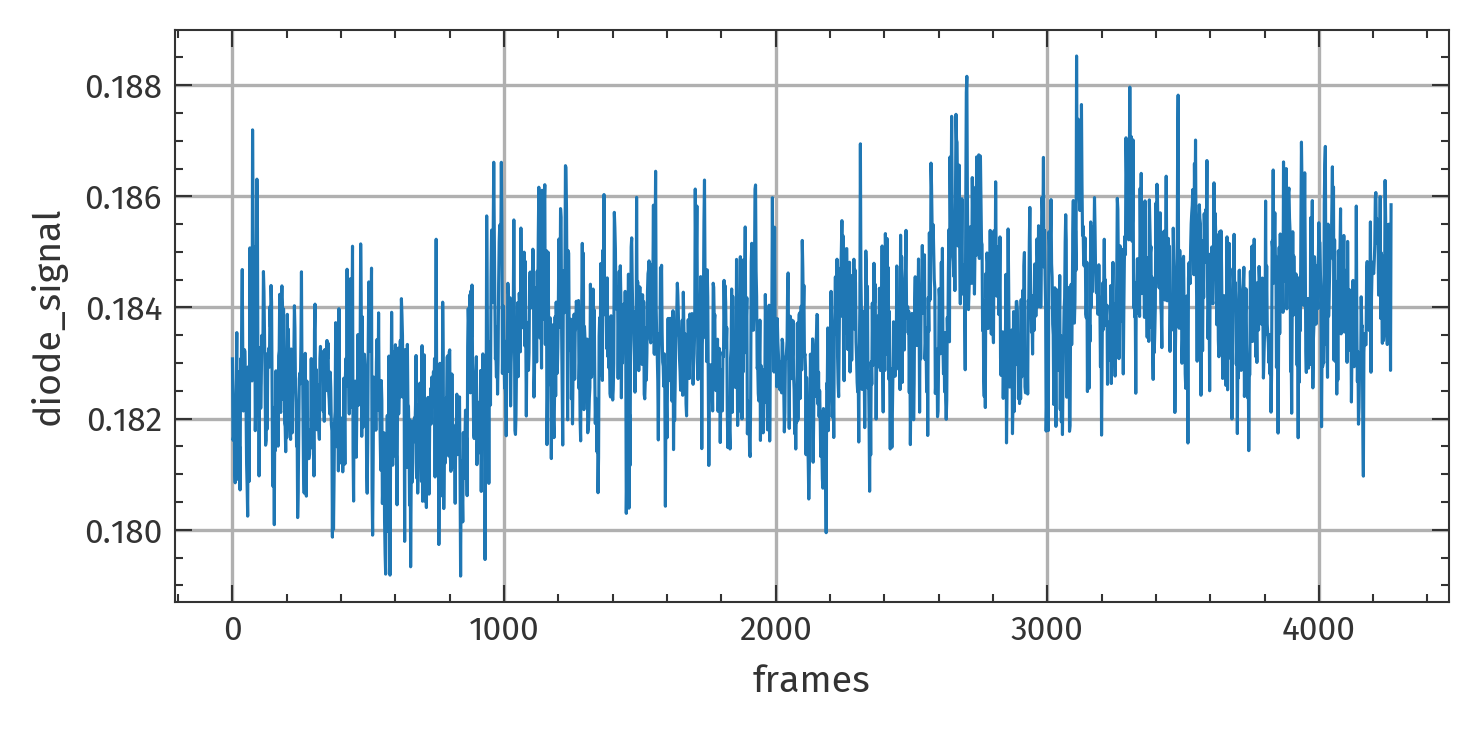

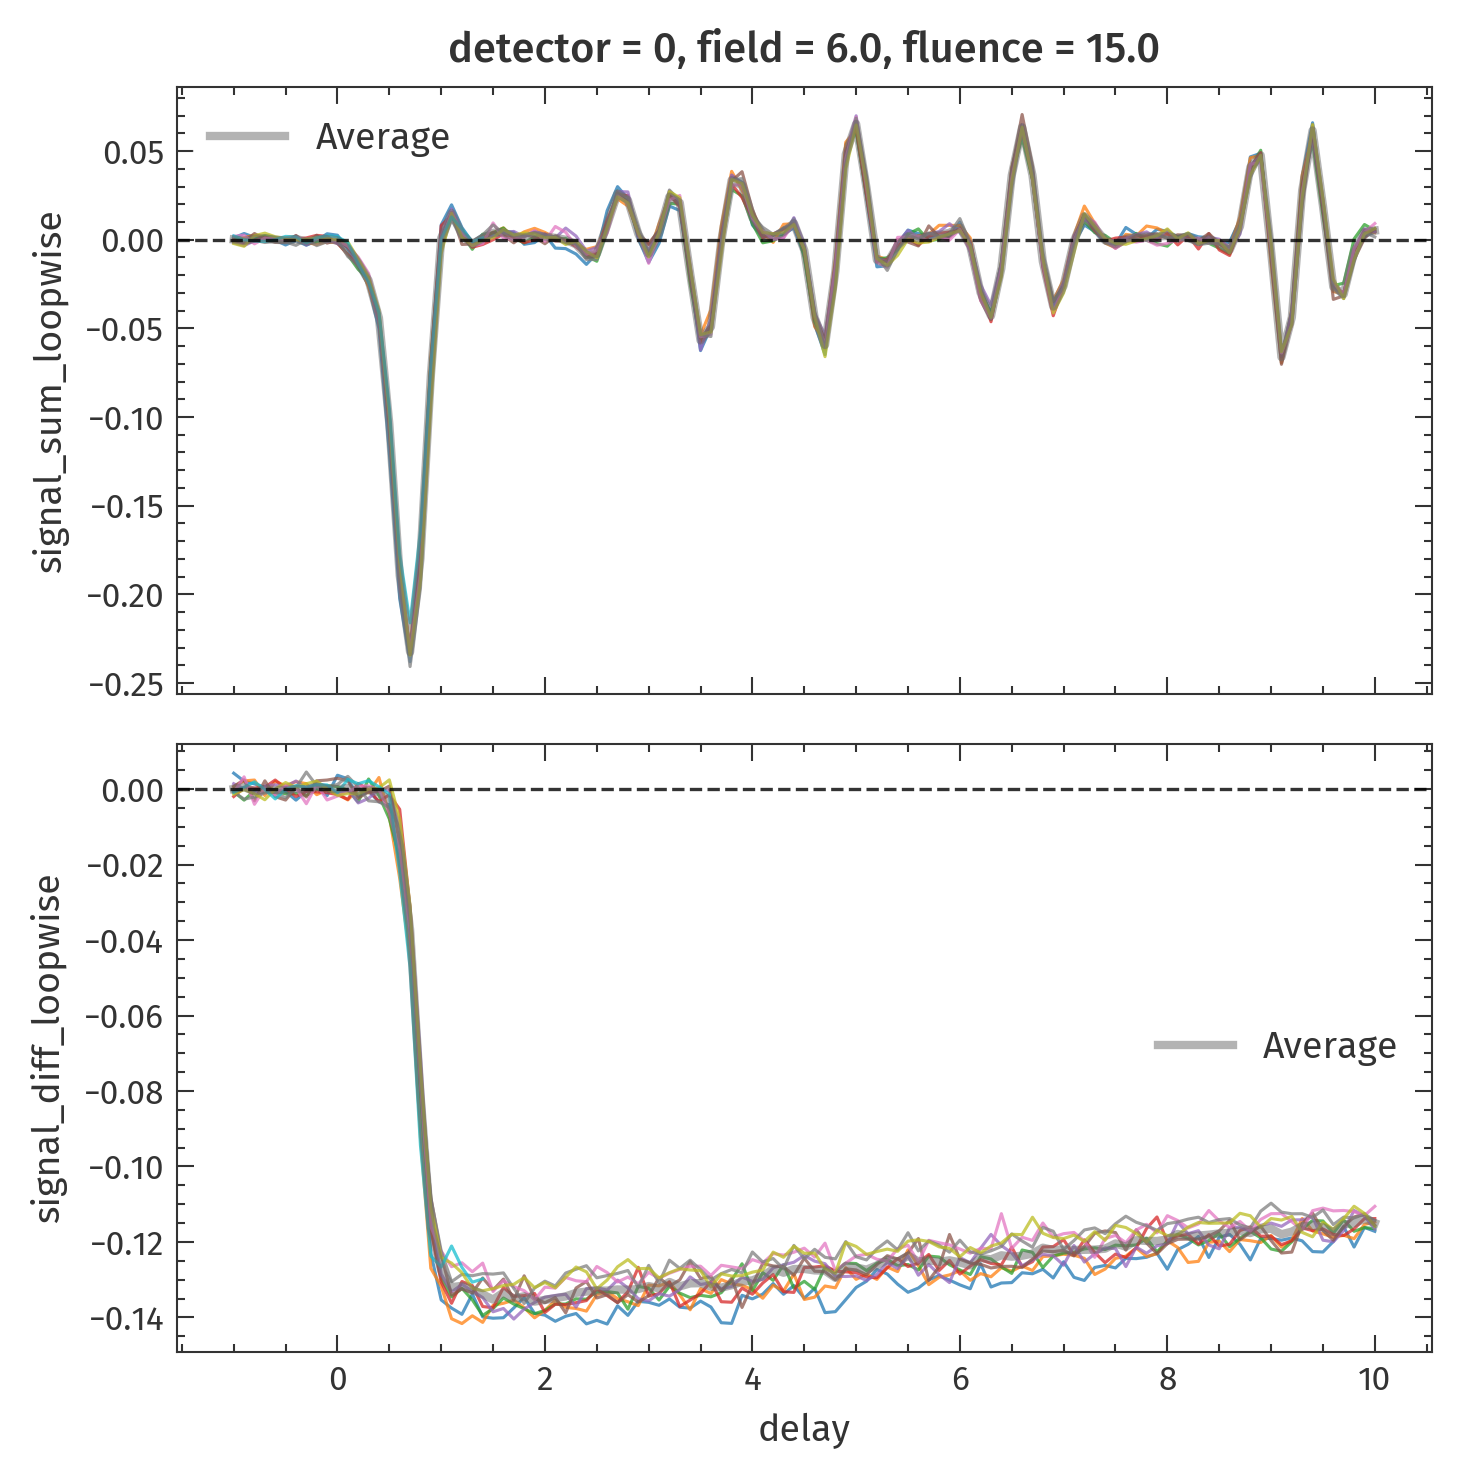

In [ ]:
processed_dataset = prop.data.p0011
scan_param = processed_dataset.attrs['scan_param']
param1 = processed_dataset.attrs['param1']
param2 = processed_dataset.attrs['param2']

fig, ax = plt.subplots(dpi=300, figsize=(5, 2.5))
processed_dataset.diode_signal.plot.line(ax=ax)
ax.grid()
plt.tight_layout()
plt.show()

detector_idx = 0  # Choose which detector to plot
# Plot loopwise data for all combinations of param1 and param2
for (i, j) in np.ndindex(len(processed_dataset[param1].values), len(processed_dataset[param2].values)):
    fig, ax = plt.subplots(2, 1, dpi=300, figsize=(5, 5), sharex=True)

    # Create selection dictionary for isel
    sel_dict = {
        'detector': detector_idx,
        param1: i,
        param2: j
    }

    # Plot sum (symmetric component) - loopwise
    processed_dataset.signal_sum_loopwise.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], alpha=0.75)
    # Overlay average
    processed_dataset.signal_sum.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], color='dimgray', linewidth=2, label='Average', alpha=0.5)

    # Plot diff (antisymmetric component) - loopwise
    processed_dataset.signal_diff_loopwise.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], alpha=0.75)
    # Overlay average
    processed_dataset.signal_diff.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], color='dimgray', linewidth=2, label='Average', alpha=0.5)

    ax[1].set_title(None)
    ax[0].set_xlabel(None)
    ax[0].set_ylabel('signal_sum_loopwise')
    ax[1].set_ylabel('signal_diff_loopwise')

    ax[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)

    ax[0].legend(ncols=4)
    ax[1].legend(ncols=4)

    plt.tight_layout()
    plt.show()


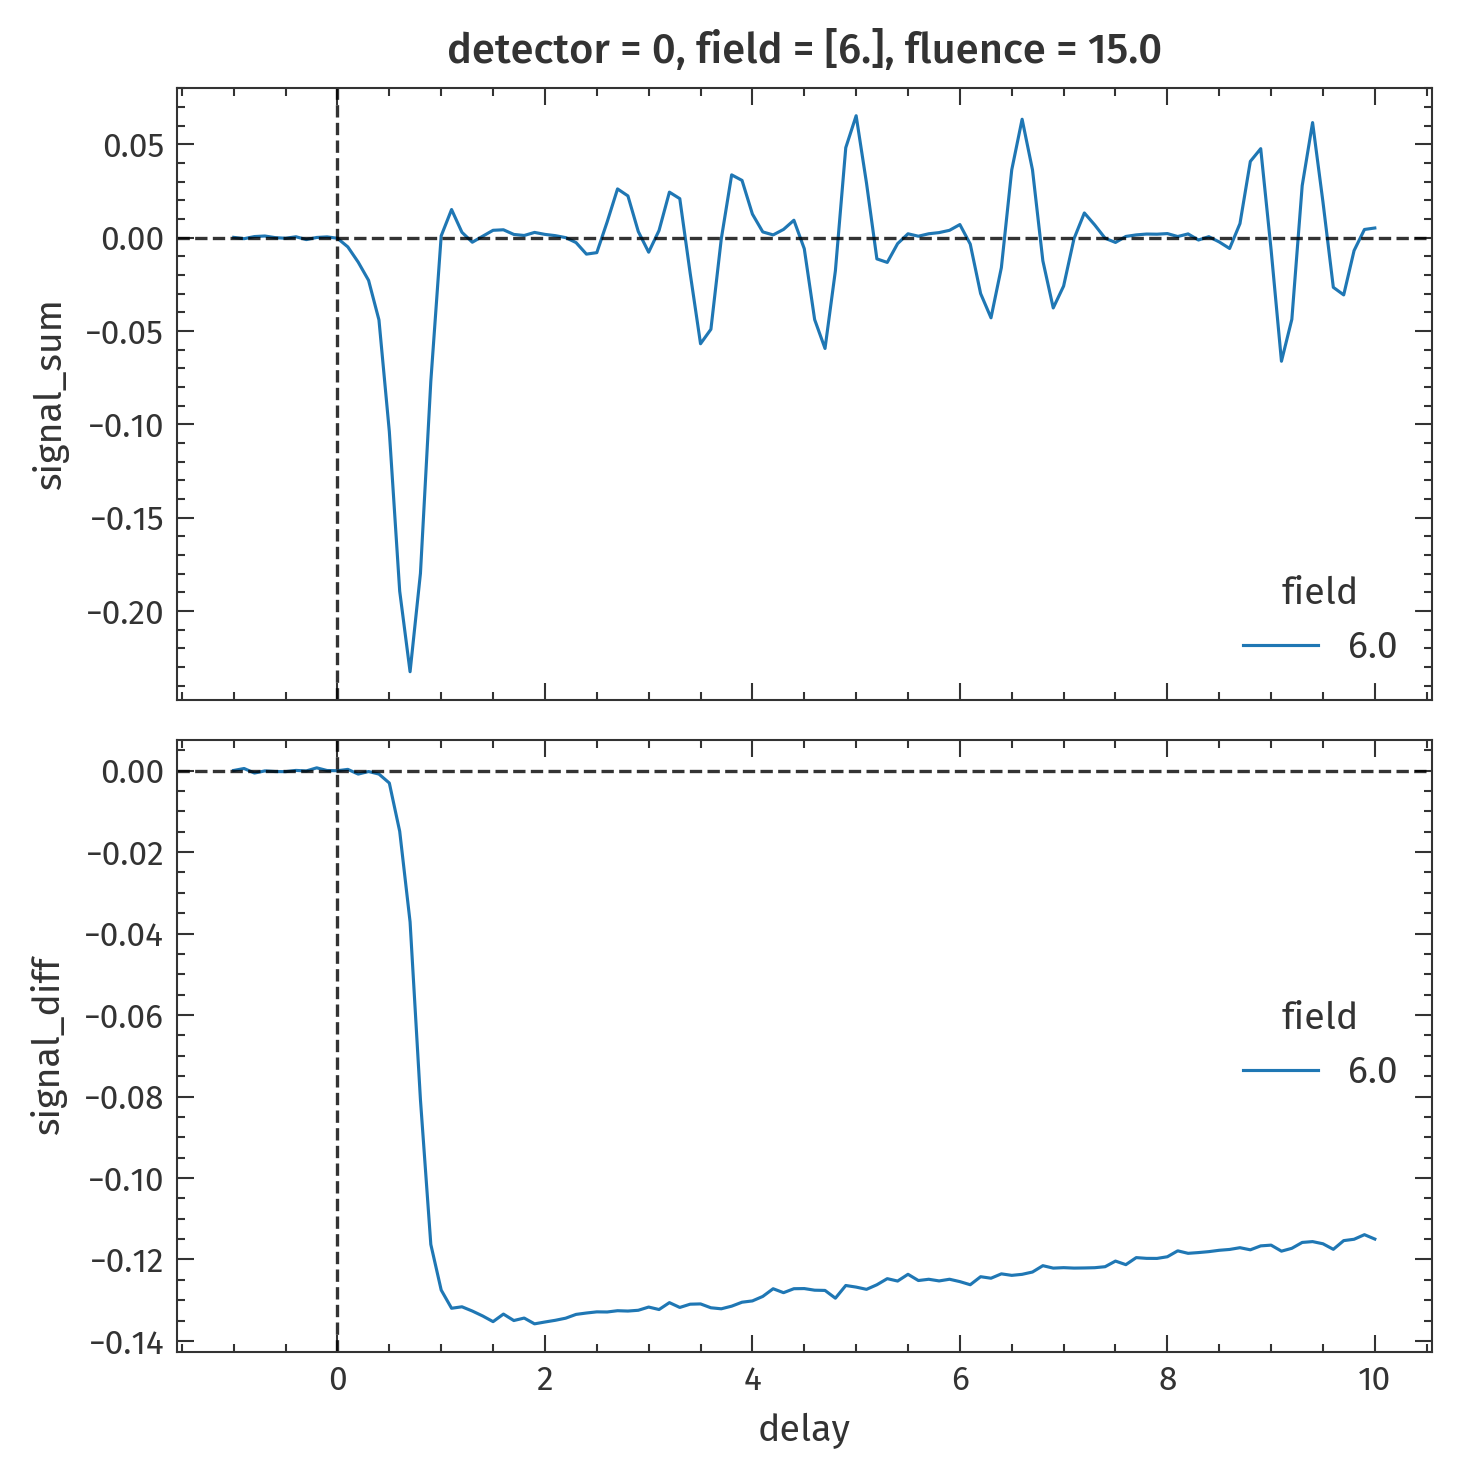

In [9]:
for param1_idx in range(len(processed_dataset[param1].values)):
    fig, ax = plt.subplots(2, 1, dpi=300, figsize=(5, 5), sharex=True)

    # Create selection dictionary
    sel_dict = {
        'detector': detector_idx,
        param1: param1_idx
    }

    # Plot sum (symmetric component)
    processed_dataset.signal_sum.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], add_legend=True)
    # Plot diff (antisymmetric component)
    processed_dataset.signal_diff.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], add_legend=True)

    ax[1].set_title(None)
    ax[0].set_xlabel(None)
    ax[0].set_ylabel('signal_sum')
    ax[1].set_ylabel('signal_diff')

    ax[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)

    plt.tight_layout()
    plt.show()

## Refining Spice Parameters

From the plots, we observe that the time-zero of the difference signal (magneto-optical component) is shifted by approximately 0.5 ps. We can correct this by updating the `t0` spice parameter.

For demonstration, we update `t0` starting from scan 0011. In practice, you might apply updates to the first scan or even the initial seed. Note that the spice dictionary needs only the parameters being changed, not all spices. The changelog then shows multiple rows: one for the initial seed and additional rows for each update.

The `update()` method accepts:

- A scan index from which the update applies (affects all subsequent scans)
- A spice dictionary with the updated values

In [10]:
prop.spice.update(11, {'t0': 0.5})
prop.spice

,t0
scan_id,
0,0.0
11,0.5


## Reprocessing with Updated Parameters

We can now reprocess the data with the updated spice configuration.

In [11]:
prop.process([6, 11, 12], overwrite=True)

Current spice configuration already saved locally.
Processing scan 0006...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 111
Unique loops: 15
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0006_processed.nc.
Processing scan 0011...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 111
Unique loops: 10
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0011_processed.nc.
Processing scan 0012...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 226
Unique loops: 10
This is a delay scan.
Processed data saved to /home/constantin/Documents/Git

## Plotting Results with Updated Time-Zero

Now we plot the results with the corrected time-zero to verify the improvement.

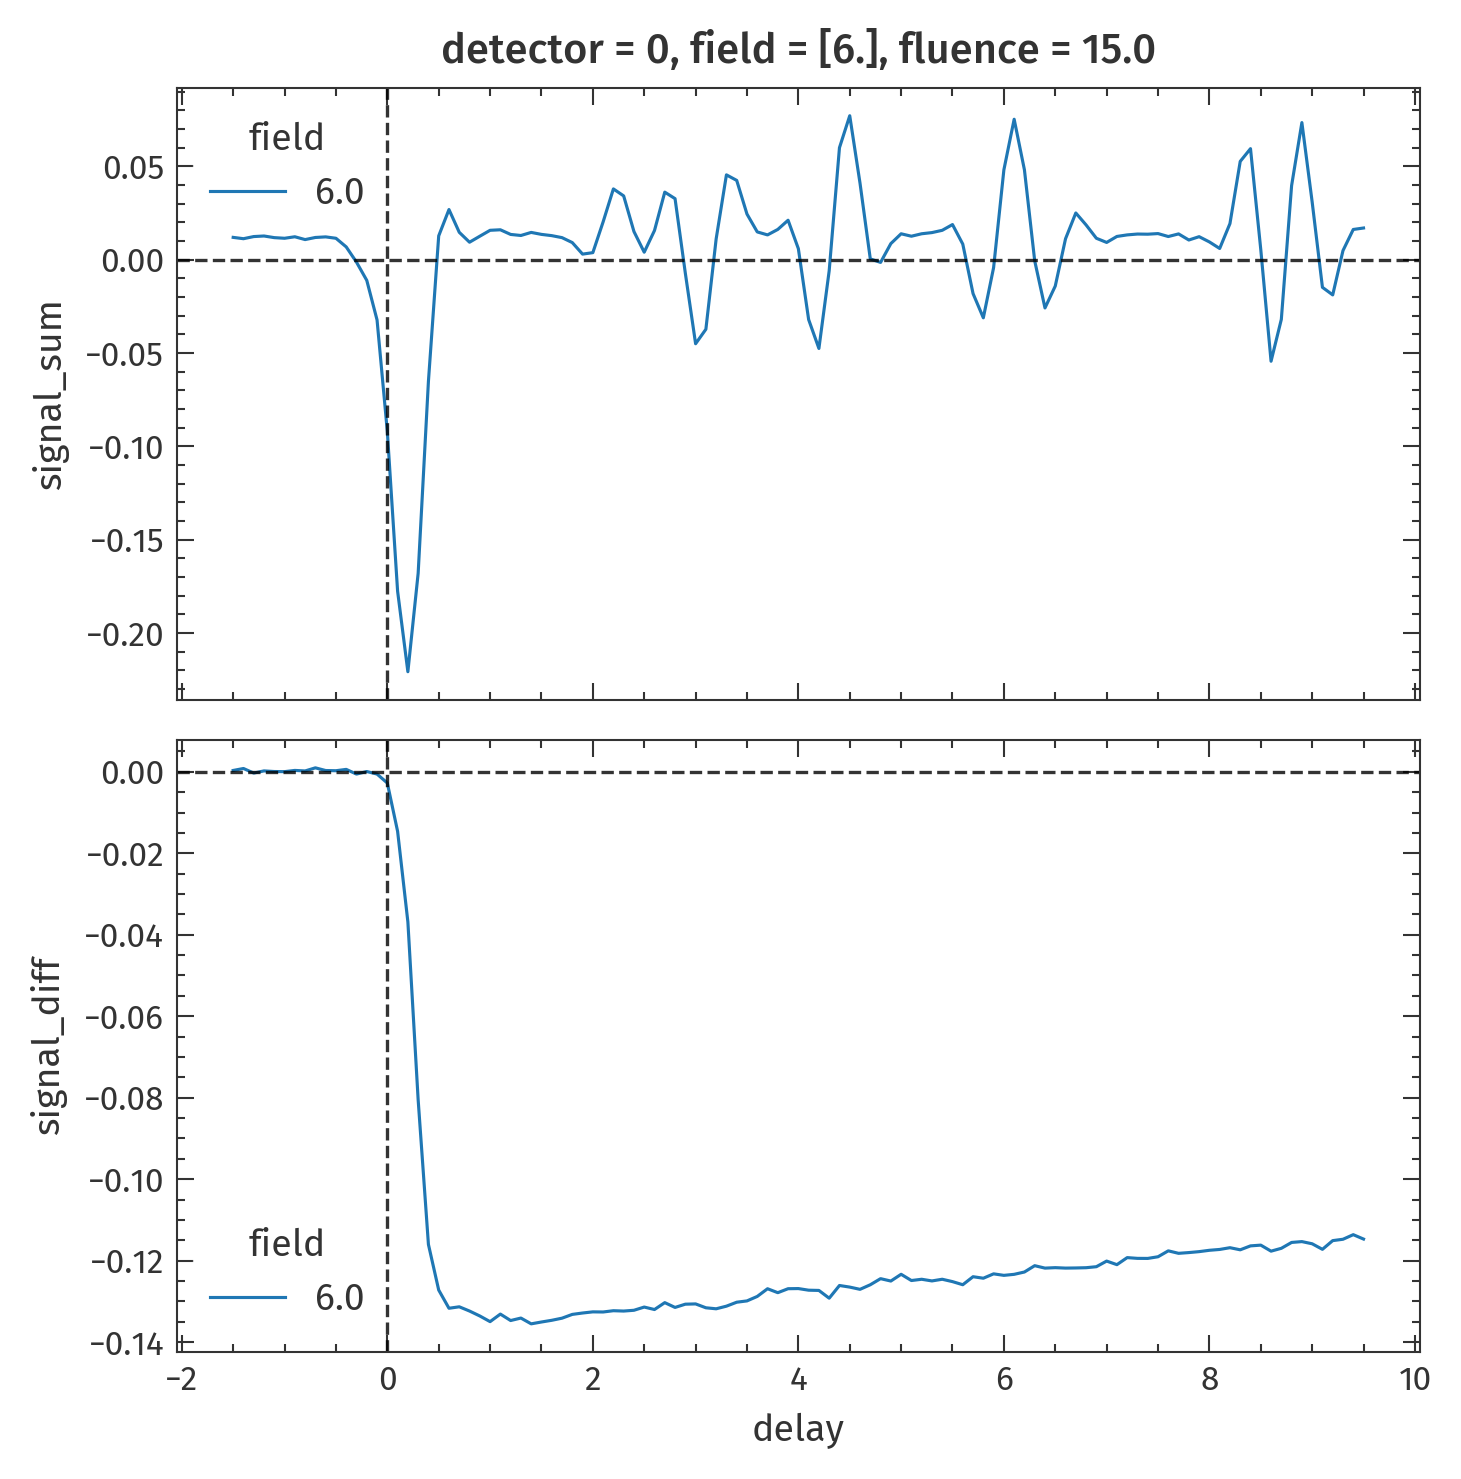

In [12]:
processed_dataset = prop.data.p0011
scan_param = processed_dataset.attrs['scan_param']
param1 = processed_dataset.attrs['param1']
param2 = processed_dataset.attrs['param2']

for param1_idx in range(len(processed_dataset[param1].values)):
    fig, ax = plt.subplots(2, 1, dpi=300, figsize=(5, 5), sharex=True)

    # Create selection dictionary
    sel_dict = {
        'detector': detector_idx,
        param1: param1_idx
    }

    # Plot sum (symmetric component)
    processed_dataset.signal_sum.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], add_legend=True)
    # Plot diff (antisymmetric component)
    processed_dataset.signal_diff.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], add_legend=True)

    ax[1].set_title(None)
    ax[0].set_xlabel(None)
    ax[0].set_ylabel('signal_sum')
    ax[1].set_ylabel('signal_diff')

    ax[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)

    plt.tight_layout()
    plt.show()